In [5]:
#1- Handling Missing Values - IT24100500

In [6]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load your dataset
file_path = 'health_lifestyle_classification.csv'
df = pd.read_csv(file_path)

# Step 3: Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
survey_code                    0
age                            0
gender                         0
height                         0
weight                         0
bmi                            0
bmi_estimated                  0
bmi_scaled                     0
bmi_corrected                  0
waist_size                     0
blood_pressure               463
heart_rate                   829
cholesterol                    0
glucose                        0
insulin                      937
sleep_hours                    0
sleep_quality                  0
work_hours                     0
physical_activity              0
daily_steps                  473
calorie_intake                 0
sugar_intake                   0
alcohol_consumption         2560
smoking_level                  0
water_intake                   0
screen_time                    0
stress_level                   0
mental_health_score            0
mental_health_support          0
education_level 

Missing values per column:
survey_code                    0
age                            0
gender                         0
height                         0
weight                         0
bmi                            0
bmi_estimated                  0
bmi_scaled                     0
bmi_corrected                  0
waist_size                     0
blood_pressure               463
heart_rate                   829
cholesterol                    0
glucose                        0
insulin                      937
sleep_hours                    0
sleep_quality                  0
work_hours                     0
physical_activity              0
daily_steps                  473
calorie_intake                 0
sugar_intake                   0
alcohol_consumption         2560
smoking_level                  0
water_intake                   0
screen_time                    0
stress_level                   0
mental_health_score            0
mental_health_support          0
education_level 

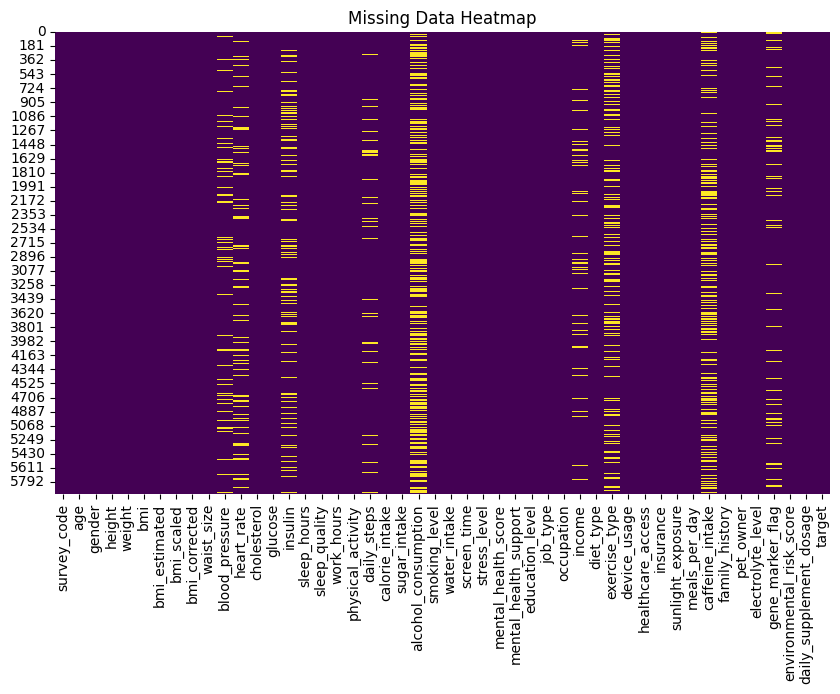


Processing column: heart_rate
Original missing: 829, Mean used: 74.78


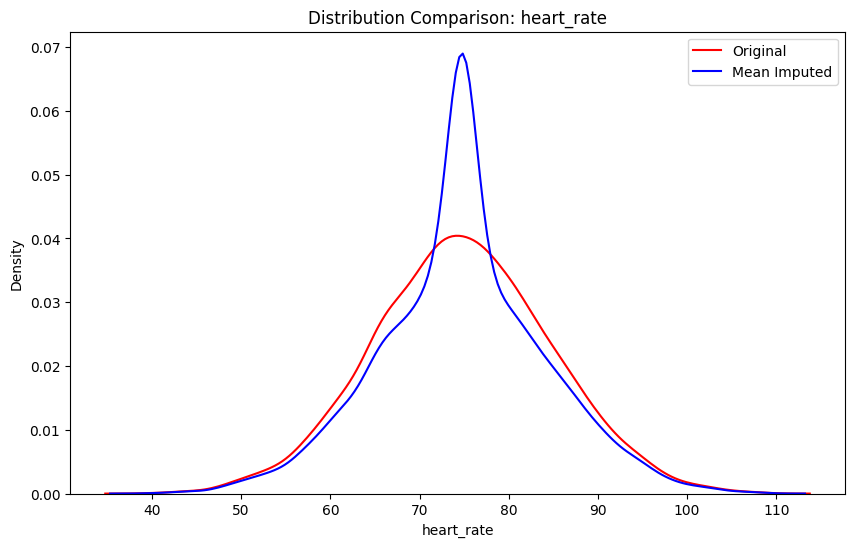


Processing column: blood_pressure
Original missing: 463, Mean used: 120.06


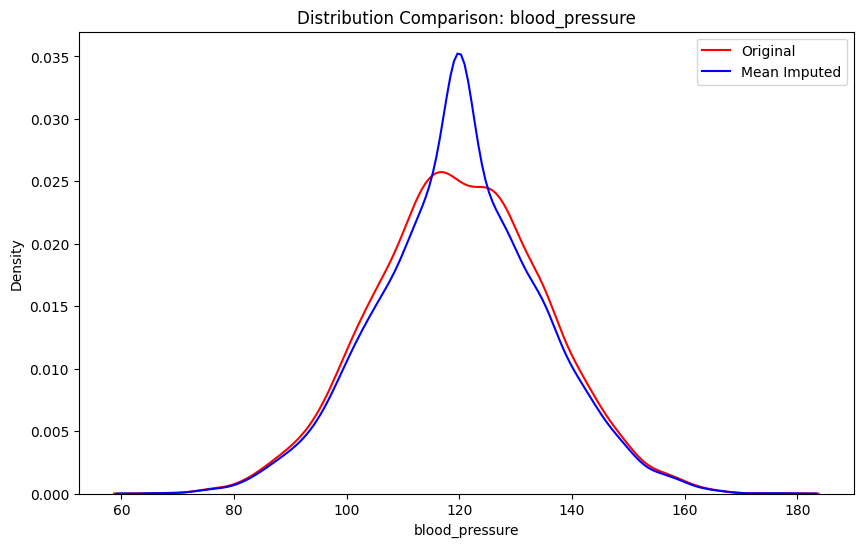


Processing column: daily_steps
Original missing: 473, Mean used: 6946.87


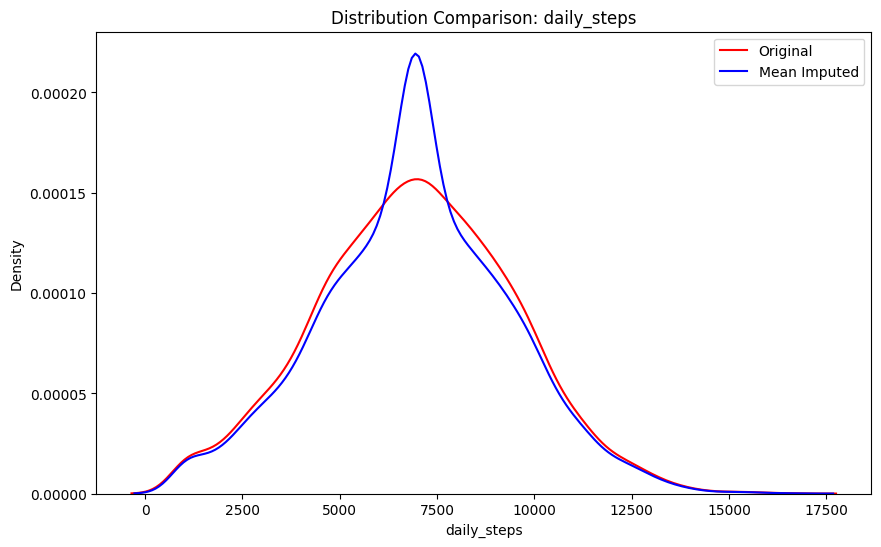

In [7]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load your dataset
file_path = 'health_lifestyle_classification.csv'
df = pd.read_csv(file_path)

# Step 3: Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Step 4: Visualize missing data
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

# Step 5: Define target columns
target_cols = ['heart_rate', 'blood_pressure', 'daily_steps']

# Step 6: Impute and compare distributions
for col in target_cols:
    print(f"\nProcessing column: {col}")

    # Convert to numeric (coerce errors to NaN)
    df[col] = pd.to_numeric(df[col], errors='coerce')

    # Fill missing values with mean
    mean_value = df[col].mean()
    imputed_col = col + '_mean'
    df[imputed_col] = df[col].fillna(mean_value)

    # Print summary stats
    print(f"Original missing: {df[col].isnull().sum()}, Mean used: {mean_value:.2f}")

    # Plot distributions if variance exists
    plt.figure(figsize=(10, 6))
    plotted = False
    if df[col].var() > 0:
        sns.kdeplot(df[col], label='Original', color='red')
        plotted = True
    else:
        print(f"Skipping KDE for {col} due to zero variance.")

    if df[imputed_col].var() > 0:
        sns.kdeplot(df[imputed_col], label='Mean Imputed', color='blue')
        plotted = True
    else:
        print(f"Skipping KDE for {imputed_col} due to zero variance.")

    if plotted:
        plt.title(f'Distribution Comparison: {col}')
        plt.legend()
        plt.show()


In [8]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
survey_code                    0
age                            0
gender                         0
height                         0
weight                         0
bmi                            0
bmi_estimated                  0
bmi_scaled                     0
bmi_corrected                  0
waist_size                     0
blood_pressure               463
heart_rate                   829
cholesterol                    0
glucose                        0
insulin                      937
sleep_hours                    0
sleep_quality                  0
work_hours                     0
physical_activity              0
daily_steps                  473
calorie_intake                 0
sugar_intake                   0
alcohol_consumption         2560
smoking_level                  0
water_intake                   0
screen_time                    0
stress_level                   0
mental_health_score            0
mental_health_support          0
education_level 

In [9]:
# Define original columns to drop
original_cols = ['heart_rate', 'blood_pressure', 'daily_steps']

# Drop them from the DataFrame
df.drop(columns=original_cols, inplace=True)

# Confirm they're gone
print("Remaining columns:")
print(df.columns)

Remaining columns:
Index(['survey_code', 'age', 'gender', 'height', 'weight', 'bmi',
       'bmi_estimated', 'bmi_scaled', 'bmi_corrected', 'waist_size',
       'cholesterol', 'glucose', 'insulin', 'sleep_hours', 'sleep_quality',
       'work_hours', 'physical_activity', 'calorie_intake', 'sugar_intake',
       'alcohol_consumption', 'smoking_level', 'water_intake', 'screen_time',
       'stress_level', 'mental_health_score', 'mental_health_support',
       'education_level', 'job_type', 'occupation', 'income', 'diet_type',
       'exercise_type', 'device_usage', 'healthcare_access', 'insurance',
       'sunlight_exposure', 'meals_per_day', 'caffeine_intake',
       'family_history', 'pet_owner', 'electrolyte_level', 'gene_marker_flag',
       'environmental_risk_score', 'daily_supplement_dosage', 'target',
       'heart_rate_mean', 'blood_pressure_mean', 'daily_steps_mean'],
      dtype='object')


In [10]:
df.rename(columns={
    'heart_rate_mean': 'heart_rate',
    'blood_pressure_mean': 'blood_pressure',
    'daily_steps_mean': 'daily_steps'
}, inplace=True)

# ✅ Confirm the change
print("Updated column names:")
print(df.columns)

Updated column names:
Index(['survey_code', 'age', 'gender', 'height', 'weight', 'bmi',
       'bmi_estimated', 'bmi_scaled', 'bmi_corrected', 'waist_size',
       'cholesterol', 'glucose', 'insulin', 'sleep_hours', 'sleep_quality',
       'work_hours', 'physical_activity', 'calorie_intake', 'sugar_intake',
       'alcohol_consumption', 'smoking_level', 'water_intake', 'screen_time',
       'stress_level', 'mental_health_score', 'mental_health_support',
       'education_level', 'job_type', 'occupation', 'income', 'diet_type',
       'exercise_type', 'device_usage', 'healthcare_access', 'insurance',
       'sunlight_exposure', 'meals_per_day', 'caffeine_intake',
       'family_history', 'pet_owner', 'electrolyte_level', 'gene_marker_flag',
       'environmental_risk_score', 'daily_supplement_dosage', 'target',
       'heart_rate', 'blood_pressure', 'daily_steps'],
      dtype='object')


In [11]:
# Define original columns to drop
original_cols = ['insulin', 'alcohol_consumption', 'income','caffeine_intake','gene_marker_flag','exercise_type']

# Drop them from the DataFrame
df.drop(columns=original_cols, inplace=True)

# Confirm they're gone
print("Remaining columns:")
print(df.columns)

Remaining columns:
Index(['survey_code', 'age', 'gender', 'height', 'weight', 'bmi',
       'bmi_estimated', 'bmi_scaled', 'bmi_corrected', 'waist_size',
       'cholesterol', 'glucose', 'sleep_hours', 'sleep_quality', 'work_hours',
       'physical_activity', 'calorie_intake', 'sugar_intake', 'smoking_level',
       'water_intake', 'screen_time', 'stress_level', 'mental_health_score',
       'mental_health_support', 'education_level', 'job_type', 'occupation',
       'diet_type', 'device_usage', 'healthcare_access', 'insurance',
       'sunlight_exposure', 'meals_per_day', 'family_history', 'pet_owner',
       'electrolyte_level', 'environmental_risk_score',
       'daily_supplement_dosage', 'target', 'heart_rate', 'blood_pressure',
       'daily_steps'],
      dtype='object')


In [12]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
survey_code                 0
age                         0
gender                      0
height                      0
weight                      0
bmi                         0
bmi_estimated               0
bmi_scaled                  0
bmi_corrected               0
waist_size                  0
cholesterol                 0
glucose                     0
sleep_hours                 0
sleep_quality               0
work_hours                  0
physical_activity           0
calorie_intake              0
sugar_intake                0
smoking_level               0
water_intake                0
screen_time                 0
stress_level                0
mental_health_score         0
mental_health_support       0
education_level             0
job_type                    0
occupation                  0
diet_type                   1
device_usage                1
healthcare_access           1
insurance                   1
sunlight_exposure           1
meals_per_day

In [13]:
df =df.dropna()
df.count()

,0
survey_code,5948
age,5948
gender,5948
height,5948
weight,5948
bmi,5948
bmi_estimated,5948
bmi_scaled,5948
bmi_corrected,5948
waist_size,5948


In [14]:
#2- Encoding Categorical Varaibles - IT24100546

In [15]:
import pandas as pd
# Now this will work
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)


Categorical columns: ['gender', 'sleep_quality', 'smoking_level', 'mental_health_support', 'education_level', 'job_type', 'occupation', 'diet_type', 'device_usage', 'healthcare_access', 'insurance', 'sunlight_exposure', 'family_history', 'pet_owner', 'target']


In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender_encoded'] = le.fit_transform(df['gender'])


In [17]:
df['sleep_quality']

,sleep_quality
0,Fair
1,Good
2,Poor
3,Good
4,Good
...,...
5943,Fair
5944,Good
5945,Fair
5946,Good


In [18]:
from sklearn.preprocessing import OrdinalEncoder

# Define the correct category order for a single column
slp_quality = ['Poor', 'Fair', 'Good', 'Excellent']

# Wrap it in another list to match the expected format for one column
oe = OrdinalEncoder(categories=[slp_quality])

# Apply encoding
df['sleep_quality_encoded'] = oe.fit_transform(df[['sleep_quality']])


In [19]:
df['sleep_quality_encoded']

,sleep_quality_encoded
0,1.0
1,2.0
2,0.0
3,2.0
4,2.0
...,...
5943,1.0
5944,2.0
5945,1.0
5946,2.0


In [20]:
df['smoking_level']

,smoking_level
0,Non-smoker
1,Light
2,Heavy
3,Heavy
4,Heavy
...,...
5943,Non-smoker
5944,Non-smoker
5945,Non-smoker
5946,Heavy


In [21]:
from sklearn.preprocessing import OrdinalEncoder

# Define the correct category order for a single column
smk_lvl = ['Non-smoker', 'Light', 'Heavy']

# Wrap it in another list to match the expected format for one column
oe = OrdinalEncoder(categories=[smk_lvl])

# Apply encoding
df['smoking_level_encoded'] = oe.fit_transform(df[['smoking_level']])


In [22]:
df['smoking_level_encoded']

,smoking_level_encoded
0,0.0
1,1.0
2,2.0
3,2.0
4,2.0
...,...
5943,0.0
5944,0.0
5945,0.0
5946,2.0


In [23]:
df['mental_health_support']

,mental_health_support
0,No
1,No
2,No
3,No
4,Yes
...,...
5943,No
5944,Yes
5945,Yes
5946,No


In [24]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['mental_health_support_encoded'] = le.fit_transform(df['mental_health_support'])

In [25]:
df['education_level']

,education_level
0,PhD
1,High School
2,Master
3,Master
4,Master
...,...
5943,PhD
5944,High School
5945,PhD
5946,Master


In [26]:
from sklearn.preprocessing import OrdinalEncoder

# Define the correct category order for a single column
edu_lvl = ['High School', 'Bachelor', 'Master','PhD']

# Wrap it in another list to match the expected format for one column
oe = OrdinalEncoder(categories=[edu_lvl])

# Apply encoding
df['education_level_encoded'] = oe.fit_transform(df[['education_level']])

In [27]:
df['education_level_encoded']

,education_level_encoded
0,3.0
1,0.0
2,2.0
3,2.0
4,2.0
...,...
5943,3.0
5944,0.0
5945,3.0
5946,2.0


In [28]:
df = pd.get_dummies(df, columns=['job_type', 'diet_type','occupation',], drop_first=True)

In [29]:
df['device_usage']

,device_usage
0,High
1,Moderate
2,High
3,Low
4,Low
...,...
5943,High
5944,Low
5945,High
5946,High


In [30]:
from sklearn.preprocessing import OrdinalEncoder

# Define the correct category order for a single column
dev_usg = ['Low', 'Moderate', 'High']

# Wrap it in another list to match the expected format for one column
oe = OrdinalEncoder(categories=[dev_usg])

# Apply encoding
df['device_usage_encoded'] = oe.fit_transform(df[['device_usage']])

In [31]:
df['healthcare_access']

,healthcare_access
0,Poor
1,Moderate
2,Good
3,Moderate
4,Moderate
...,...
5943,Poor
5944,Good
5945,Moderate
5946,Moderate


In [32]:
from sklearn.preprocessing import OrdinalEncoder

# Define the correct category order for a single column
hlt_accs = ['Poor', 'Moderate', 'Good']

# Wrap it in another list to match the expected format for one column
oe = OrdinalEncoder(categories=[hlt_accs])

# Apply encoding
df['healthcare_access_encoded'] = oe.fit_transform(df[['healthcare_access']])

In [33]:
df['healthcare_access_encoded']

,healthcare_access_encoded
0,0.0
1,1.0
2,2.0
3,1.0
4,1.0
...,...
5943,0.0
5944,2.0
5945,1.0
5946,1.0


In [34]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['insurance_encoded'] = le.fit_transform(df['insurance'])

In [35]:
df['insurance_encoded']

,insurance_encoded
0,0
1,0
2,1
3,0
4,1
...,...
5943,1
5944,1
5945,1
5946,1


In [36]:
df['sunlight_exposure']

,sunlight_exposure
0,High
1,High
2,High
3,High
4,High
...,...
5943,Low
5944,Moderate
5945,High
5946,Moderate


In [37]:
from sklearn.preprocessing import OrdinalEncoder

# Define the correct category order for a single column
sun_exp = ['Low', 'Moderate', 'High']

# Wrap it in another list to match the expected format for one column
oe = OrdinalEncoder(categories=[sun_exp])

# Apply encoding
df['sunlight_exposure_encoded'] = oe.fit_transform(df[['sunlight_exposure']])

In [38]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['family_history_encoded'] = le.fit_transform(df['family_history'])

In [39]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['pet_owner_encoded'] = le.fit_transform(df['pet_owner'])

In [40]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['target_encoded'] = le.fit_transform(df['target'])

In [41]:
print(df.columns)

Index(['survey_code', 'age', 'gender', 'height', 'weight', 'bmi',
       'bmi_estimated', 'bmi_scaled', 'bmi_corrected', 'waist_size',
       'cholesterol', 'glucose', 'sleep_hours', 'sleep_quality', 'work_hours',
       'physical_activity', 'calorie_intake', 'sugar_intake', 'smoking_level',
       'water_intake', 'screen_time', 'stress_level', 'mental_health_score',
       'mental_health_support', 'education_level', 'device_usage',
       'healthcare_access', 'insurance', 'sunlight_exposure', 'meals_per_day',
       'family_history', 'pet_owner', 'electrolyte_level',
       'environmental_risk_score', 'daily_supplement_dosage', 'target',
       'heart_rate', 'blood_pressure', 'daily_steps', 'gender_encoded',
       'sleep_quality_encoded', 'smoking_level_encoded',
       'mental_health_support_encoded', 'education_level_encoded',
       'job_type_Labor', 'job_type_Office', 'job_type_Service',
       'job_type_Tech', 'job_type_Unemployed', 'diet_type_Omnivore',
       'diet_type_Vegan'

In [42]:
#3- Outlier Detection and Removal - IT24100488

In [43]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    print(f"{column}: Removed {df.shape[0] - filtered_df.shape[0]} outliers")
    return filtered_df


In [44]:
df.head()

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,...,occupation_Engineer,occupation_Farmer,occupation_Teacher,device_usage_encoded,healthcare_access_encoded,insurance_encoded,sunlight_exposure_encoded,family_history_encoded,pet_owner_encoded,target_encoded
0,1,56,Male,173.416872,56.886640,18.915925,18.915925,56.747776,18.989117,72.165130,...,False,True,False,2.0,0.0,0,2.0,0,1,1
1,2,69,Female,163.207380,97.799859,36.716278,36.716278,110.148833,36.511417,85.598889,...,True,False,False,1.0,1.0,0,2.0,1,0,1
2,3,46,Male,177.281966,80.687562,25.673050,25.673050,77.019151,25.587429,90.295030,...,False,False,True,2.0,2.0,1,2.0,0,0,1
3,4,32,Female,172.101255,63.142868,21.318480,21.318480,63.955440,21.177109,100.504211,...,False,False,True,0.0,1.0,0,2.0,0,1,1
4,5,60,Female,163.608816,40.000000,14.943302,14.943302,44.829907,14.844299,69.021150,...,False,False,False,0.0,1.0,1,2.0,1,1,1


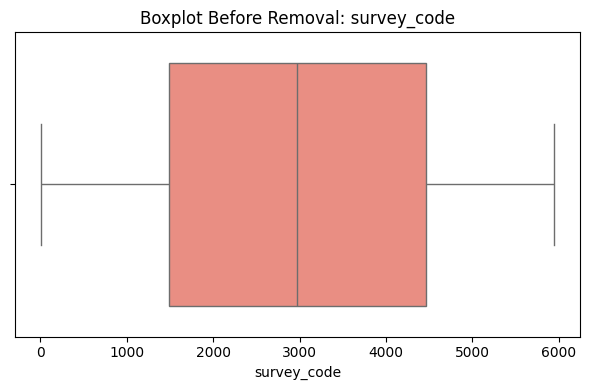

survey_code: Removed 0 outliers


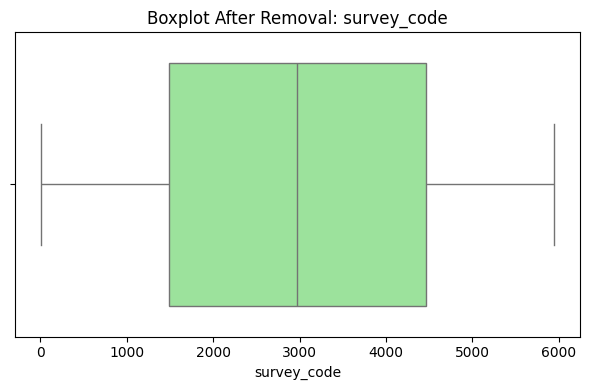

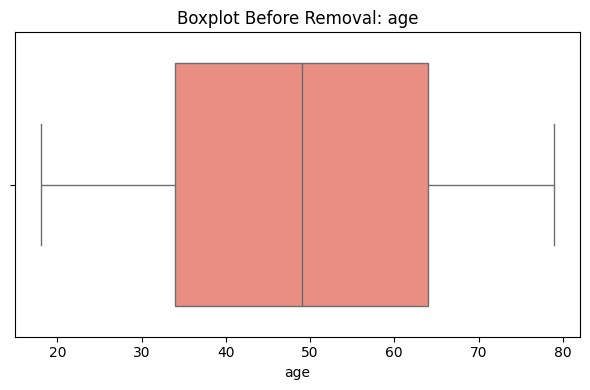

age: Removed 0 outliers


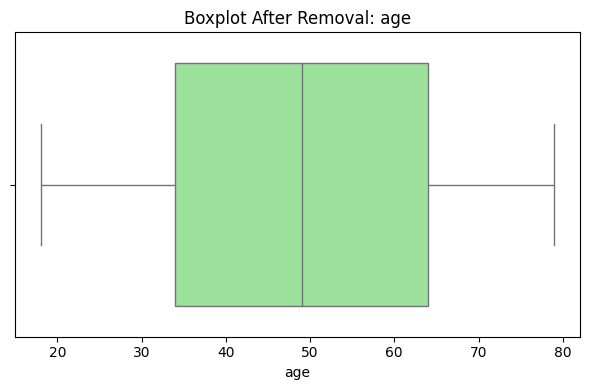

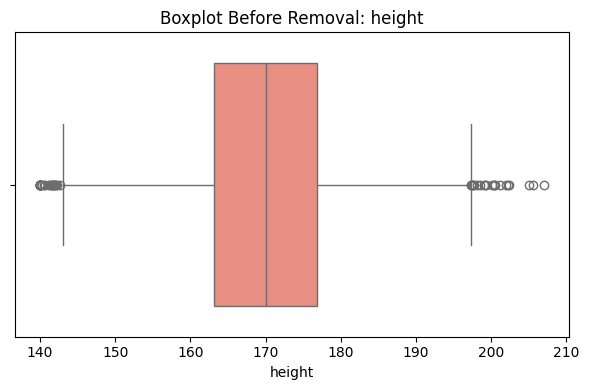

height: Removed 52 outliers


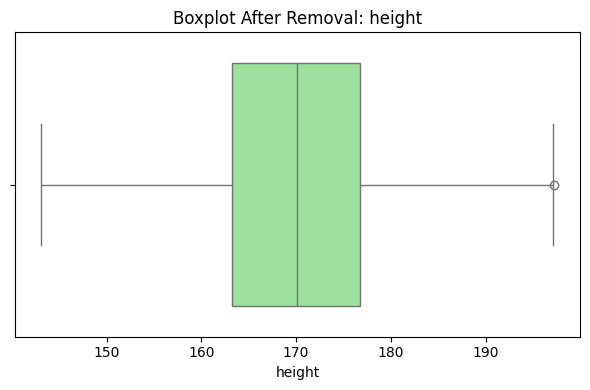

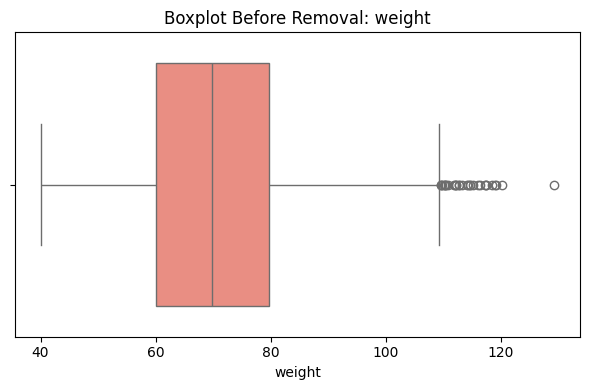

weight: Removed 30 outliers


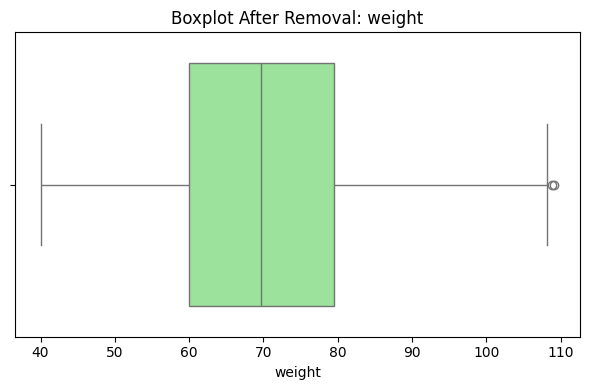

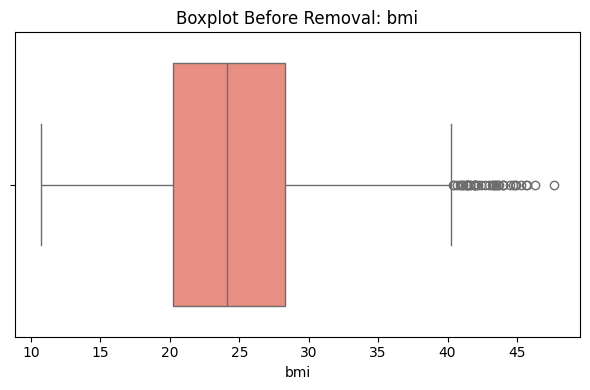

bmi: Removed 42 outliers


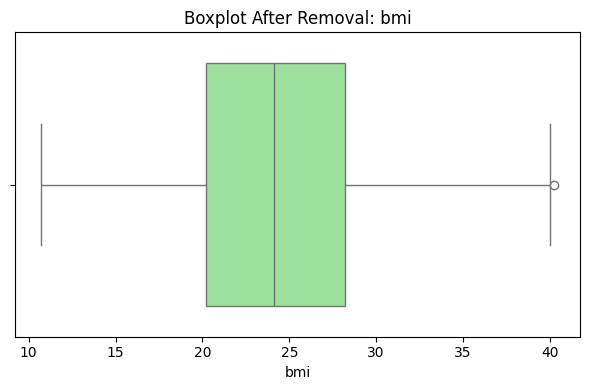

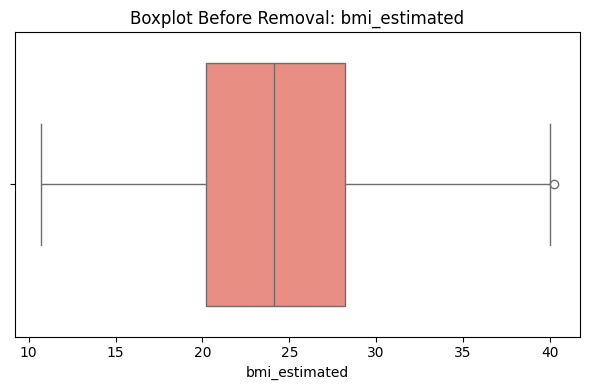

bmi_estimated: Removed 1 outliers


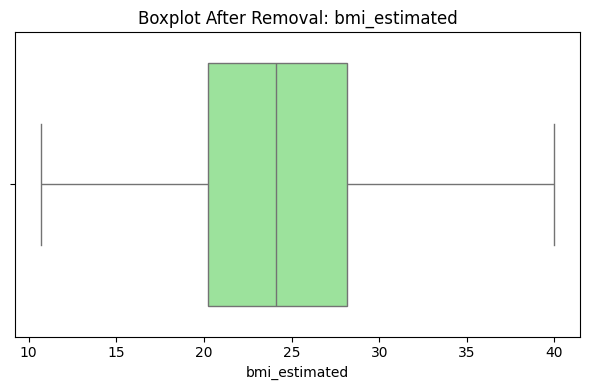

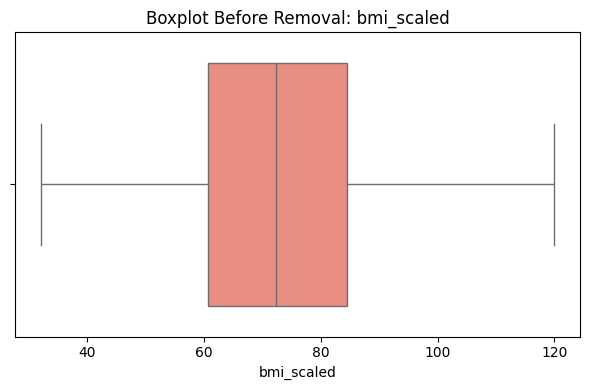

bmi_scaled: Removed 0 outliers


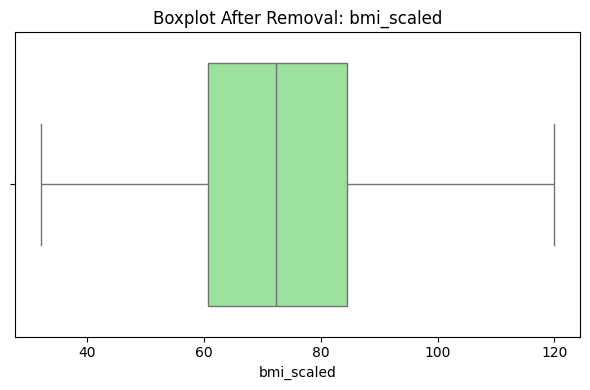

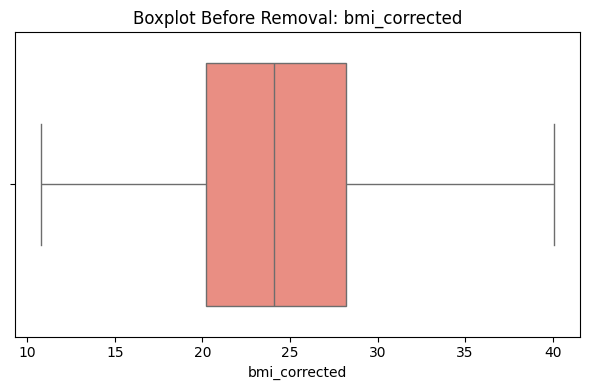

bmi_corrected: Removed 0 outliers


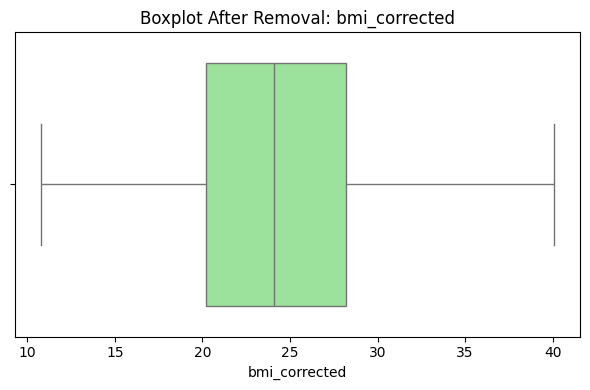

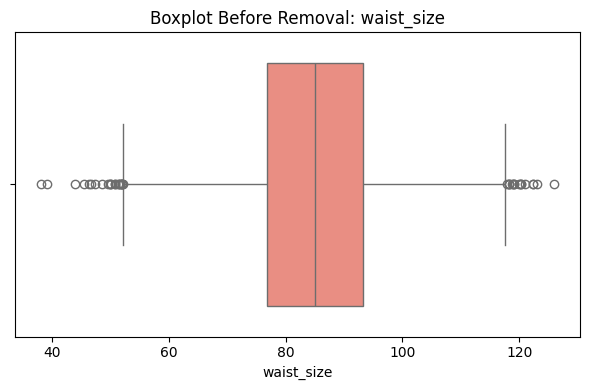

waist_size: Removed 40 outliers


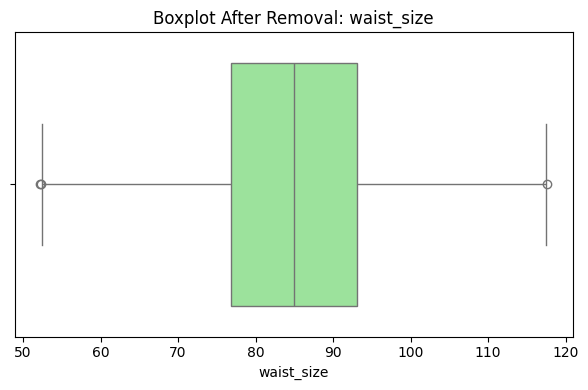

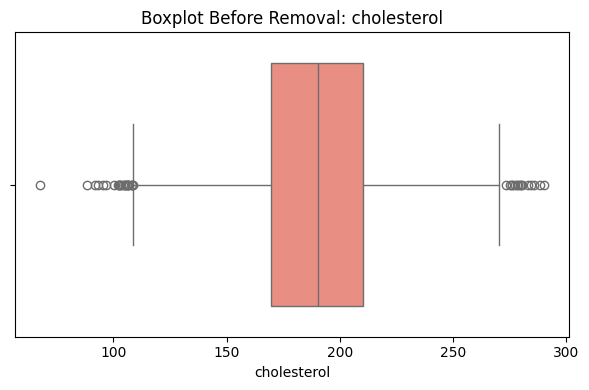

cholesterol: Removed 40 outliers


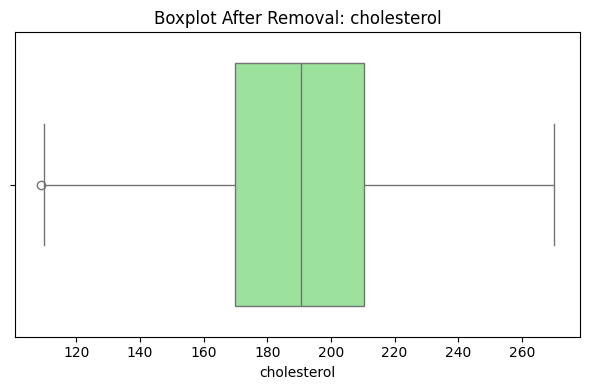

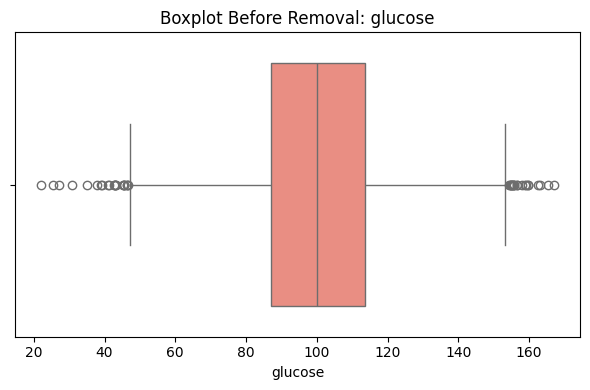

glucose: Removed 43 outliers


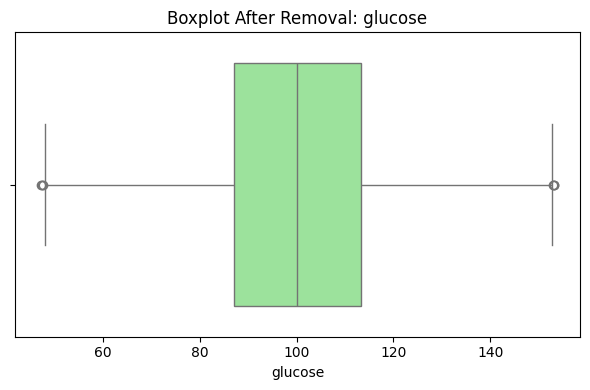

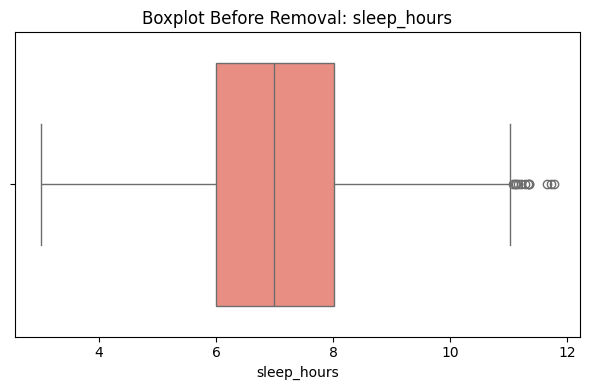

sleep_hours: Removed 12 outliers


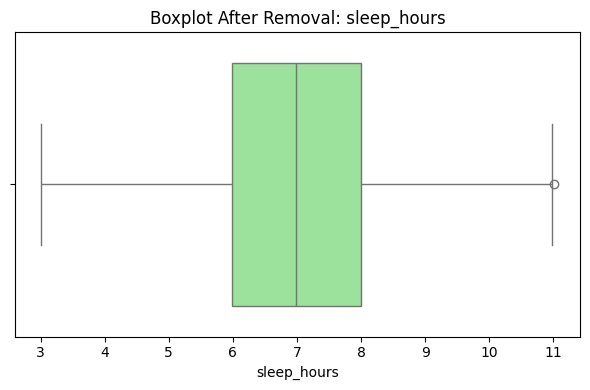

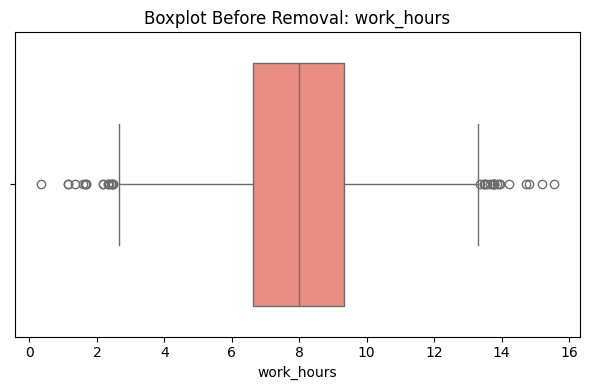

work_hours: Removed 37 outliers


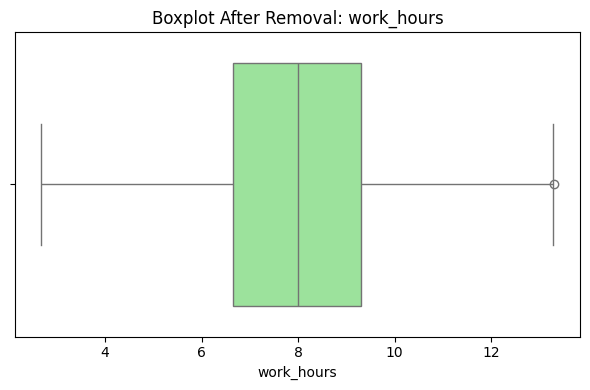

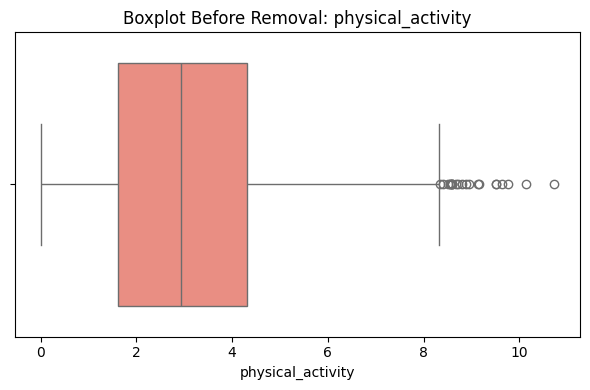

physical_activity: Removed 22 outliers


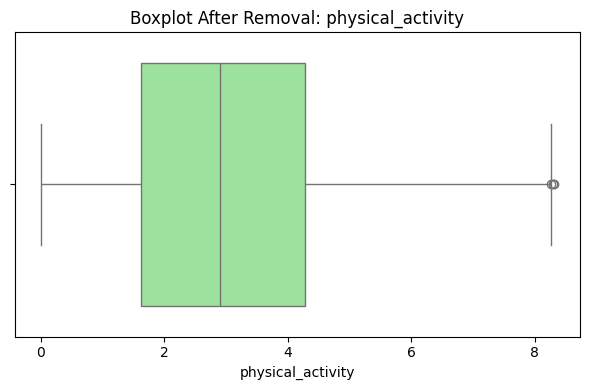

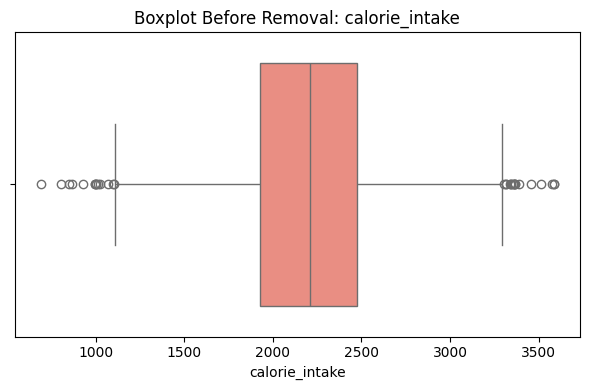

calorie_intake: Removed 31 outliers


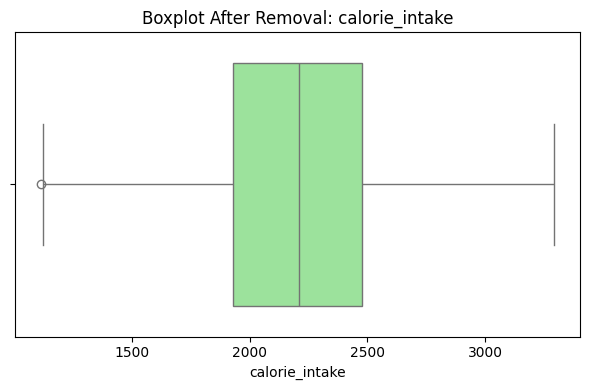

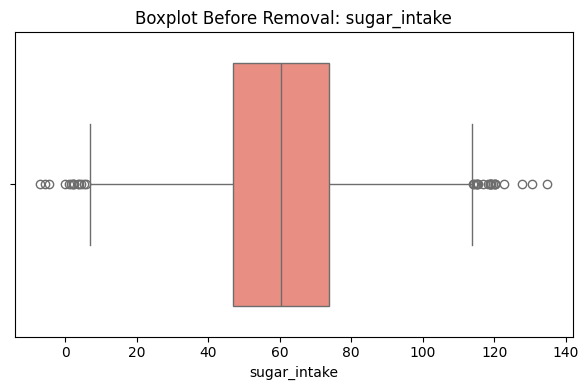

sugar_intake: Removed 35 outliers


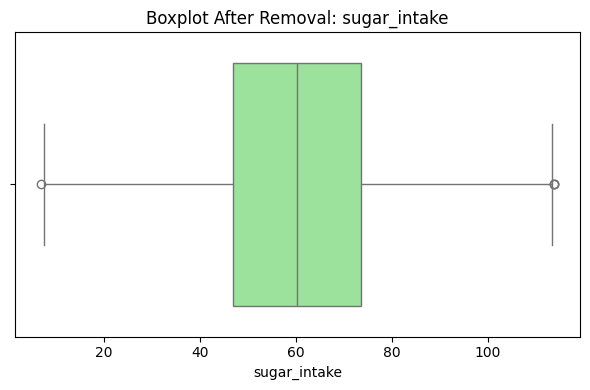

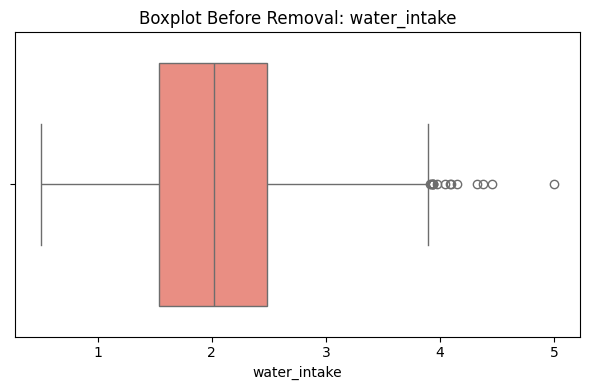

water_intake: Removed 15 outliers


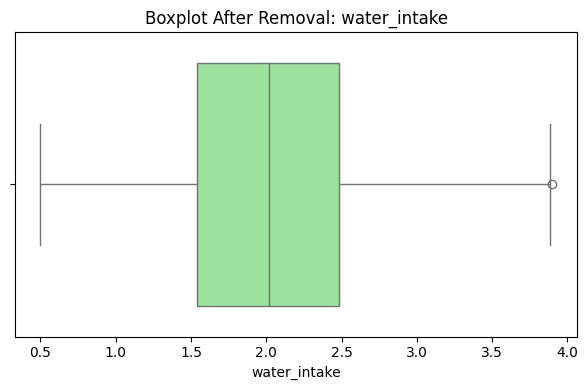

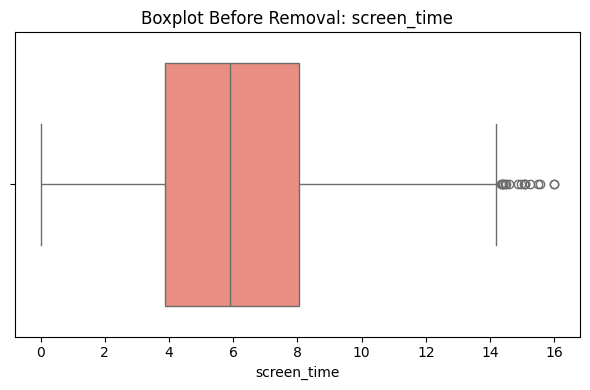

screen_time: Removed 17 outliers


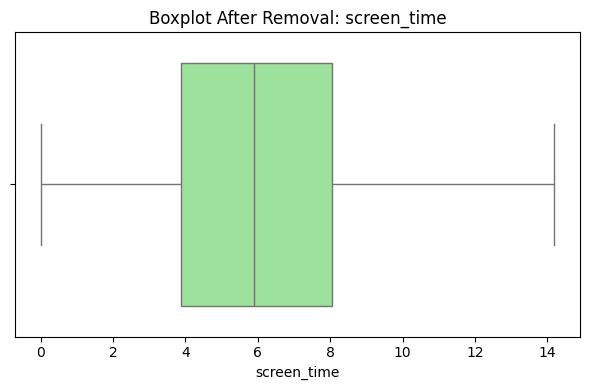

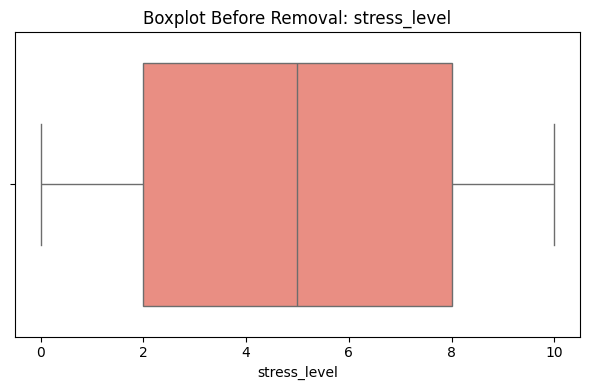

stress_level: Removed 0 outliers


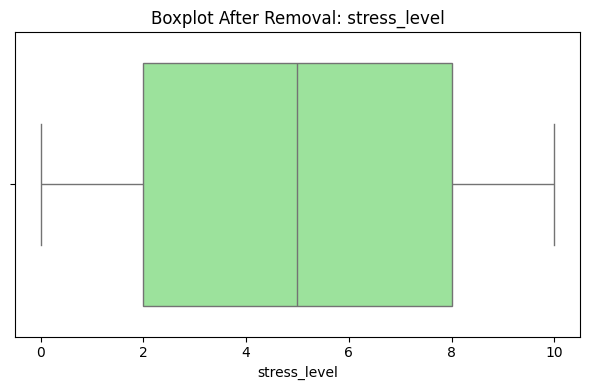

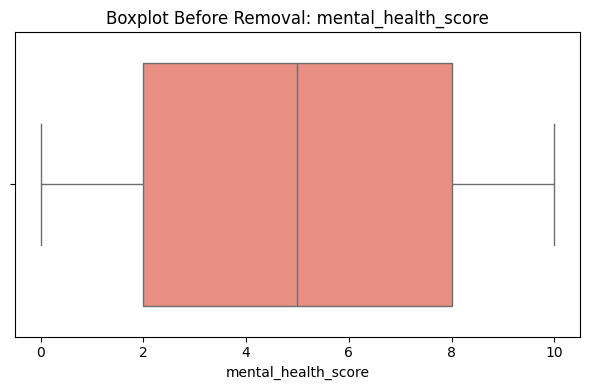

mental_health_score: Removed 0 outliers


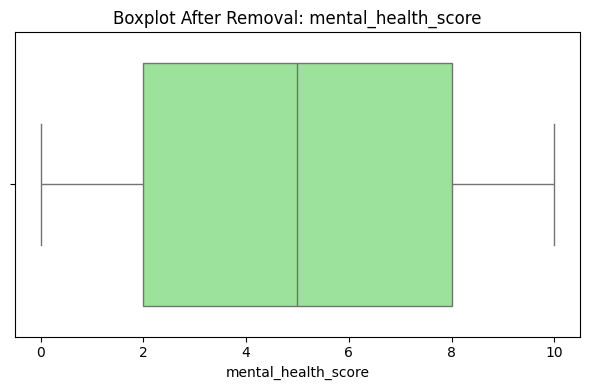

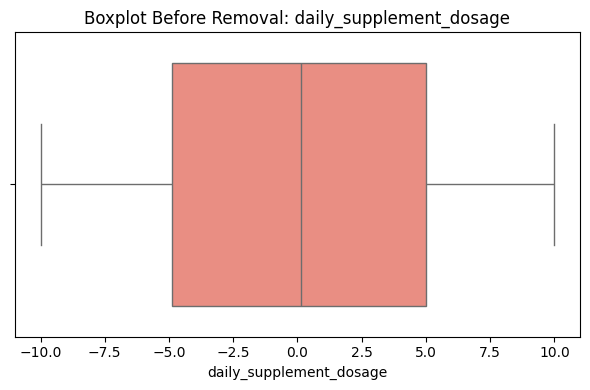

daily_supplement_dosage: Removed 0 outliers


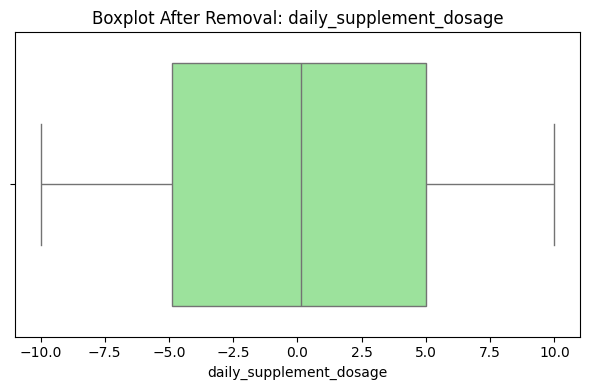

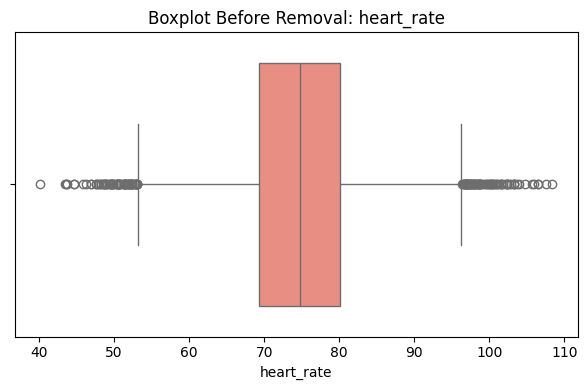

heart_rate: Removed 148 outliers


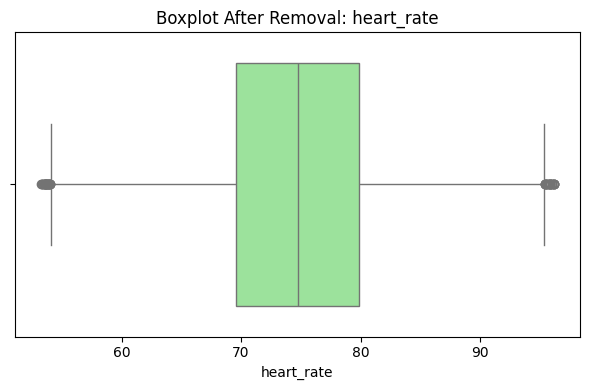

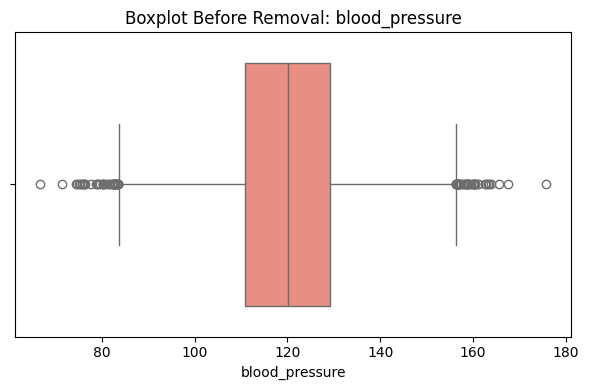

blood_pressure: Removed 82 outliers


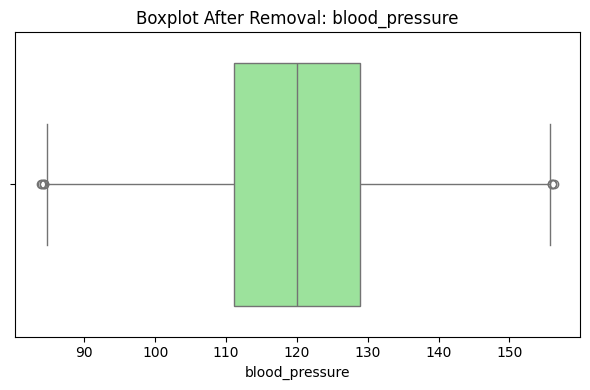

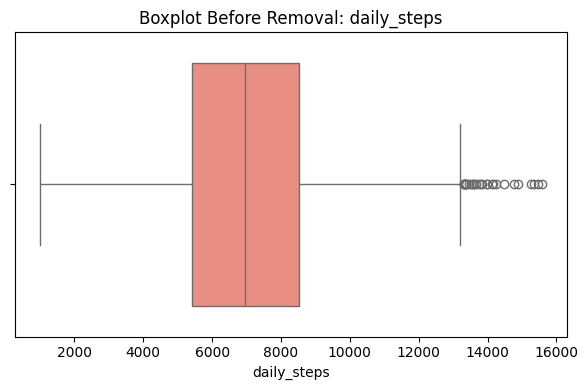

daily_steps: Removed 29 outliers


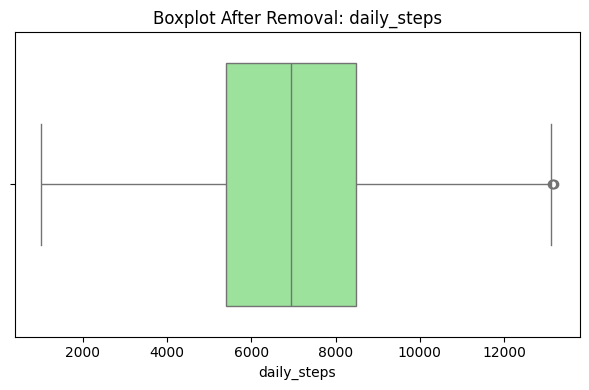

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Define the IQR-based outlier removal function with box plots
def remove_outliers_iqr(df, column):
    # 📦 Boxplot before removal
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column], color='salmon')
    plt.title(f'Boxplot Before Removal: {column}')
    plt.tight_layout()
    plt.show()

    # ✂️ IQR filtering
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    removed = df.shape[0] - filtered_df.shape[0]
    print(f"{column}: Removed {removed} outliers")

    # 📦 Boxplot after removal
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=filtered_df[column], color='lightgreen')
    plt.title(f'Boxplot After Removal: {column}')
    plt.tight_layout()
    plt.show()

    return filtered_df

# Step 2: Define target columns for outlier removal
outlier_cols = [
    'survey_code', 'age', 'height', 'weight', 'bmi', 'bmi_estimated', 'bmi_scaled',
    'bmi_corrected', 'waist_size', 'cholesterol', 'glucose', 'sleep_hours', 'work_hours',
    'physical_activity', 'calorie_intake', 'sugar_intake', 'water_intake', 'screen_time', 'stress_level',
    'mental_health_score', 'daily_supplement_dosage', 'heart_rate', 'blood_pressure', 'daily_steps'
]

# Step 3: Apply outlier removal iteratively
for col in outlier_cols:
    if col in df.columns:
        df = remove_outliers_iqr(df, col)
    else:
        print(f"⚠️ Column '{col}' not found in DataFrame")

In [46]:
#4- Feature Scale and Normalize - IT24100418

In [47]:
# Select numeric columns (excluding binary/categorical)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns for scaling:", numeric_cols)

Numeric columns for scaling: ['survey_code', 'age', 'height', 'weight', 'bmi', 'bmi_estimated', 'bmi_scaled', 'bmi_corrected', 'waist_size', 'cholesterol', 'glucose', 'sleep_hours', 'work_hours', 'physical_activity', 'calorie_intake', 'sugar_intake', 'water_intake', 'screen_time', 'stress_level', 'mental_health_score', 'meals_per_day', 'electrolyte_level', 'environmental_risk_score', 'daily_supplement_dosage', 'heart_rate', 'blood_pressure', 'daily_steps', 'gender_encoded', 'sleep_quality_encoded', 'smoking_level_encoded', 'mental_health_support_encoded', 'education_level_encoded', 'device_usage_encoded', 'healthcare_access_encoded', 'insurance_encoded', 'sunlight_exposure_encoded', 'family_history_encoded', 'pet_owner_encoded', 'target_encoded']


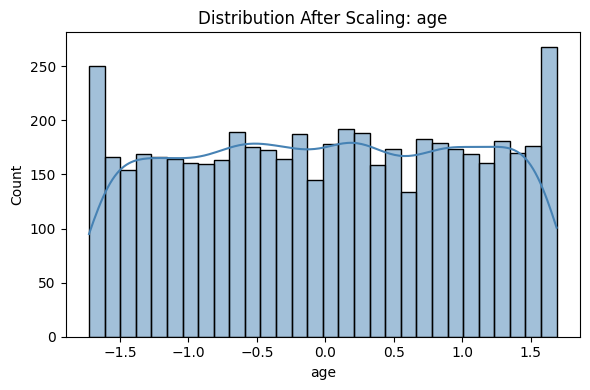

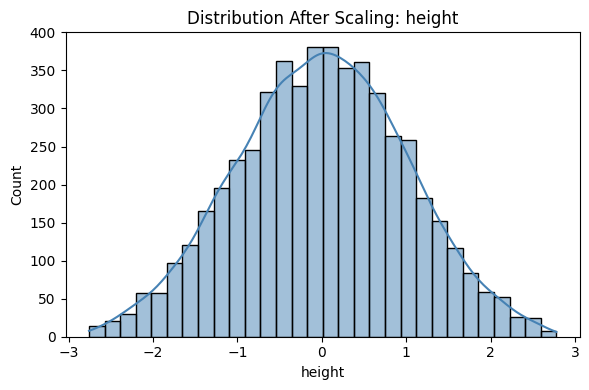

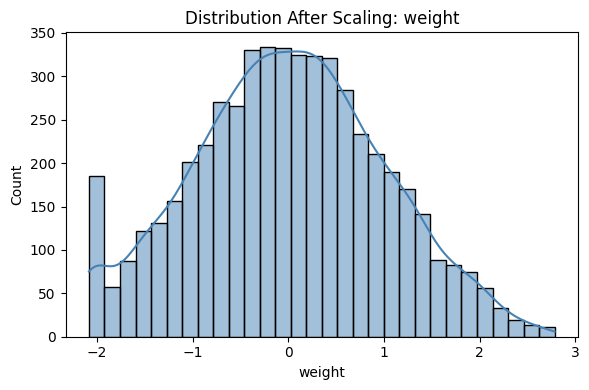

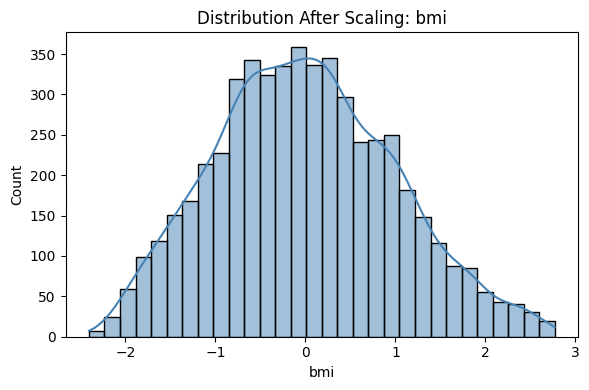

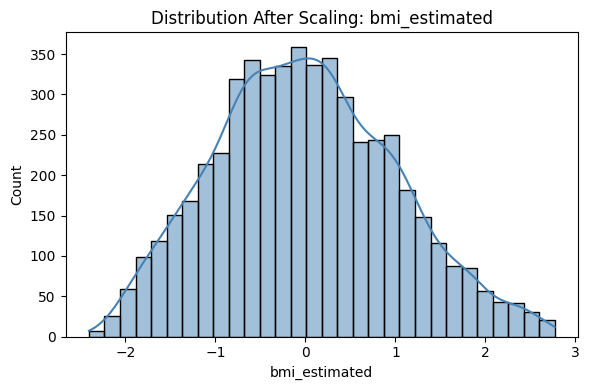

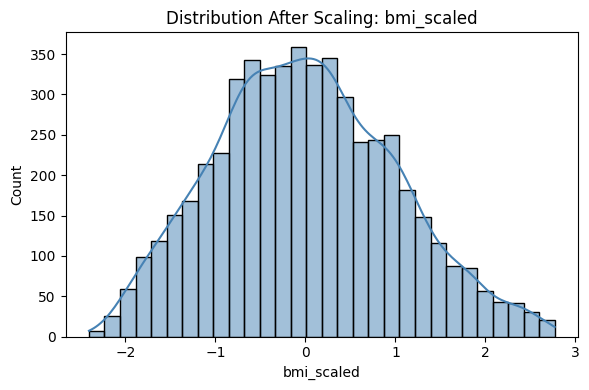

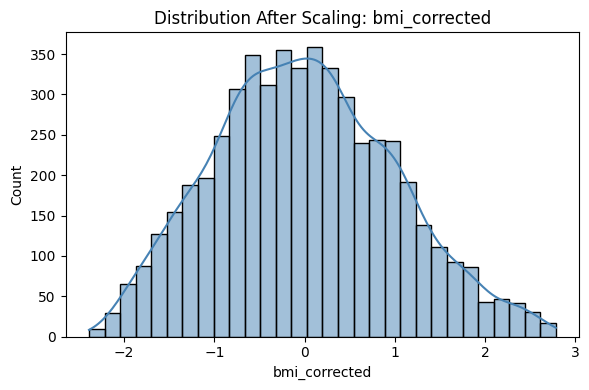

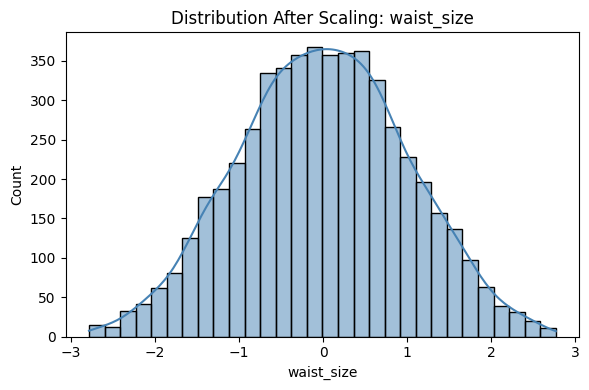

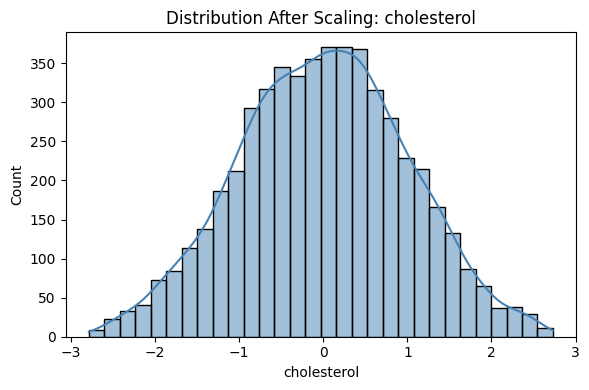

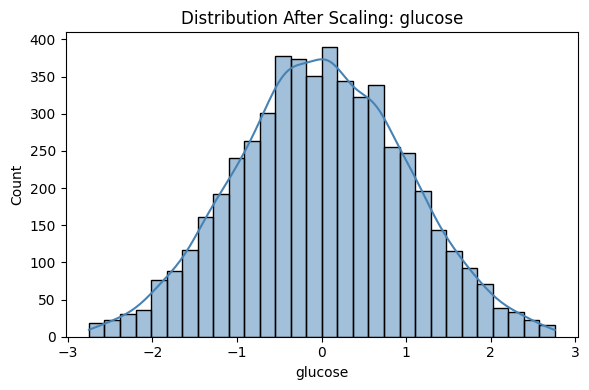

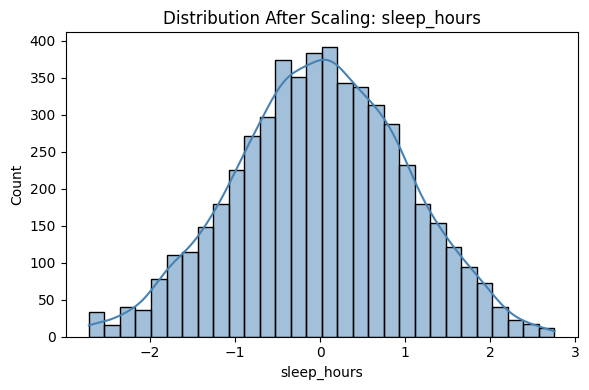

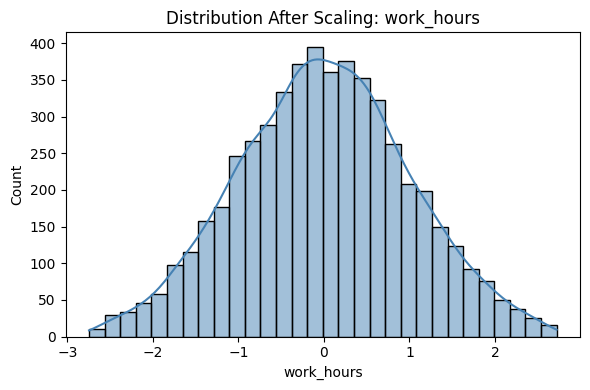

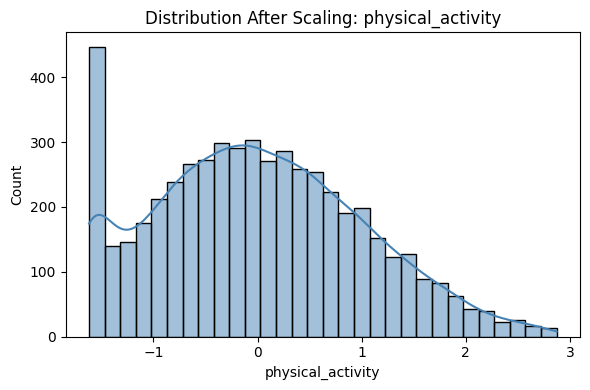

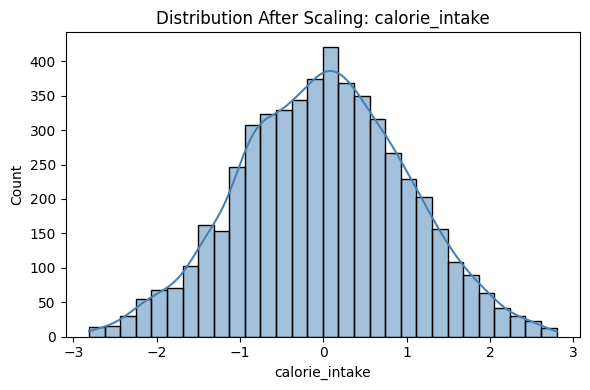

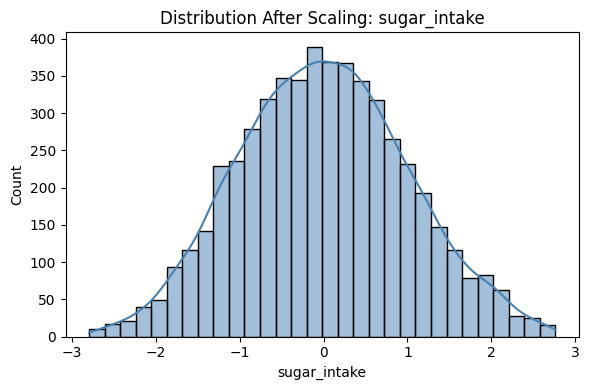

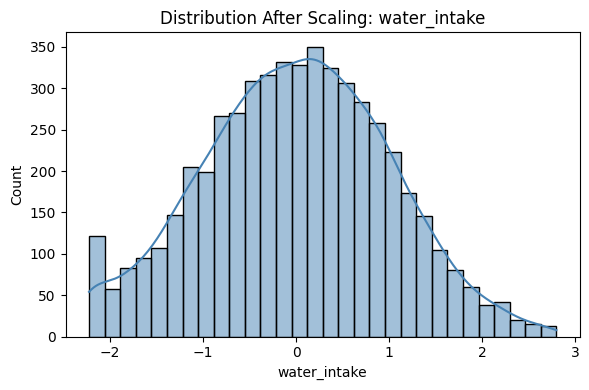

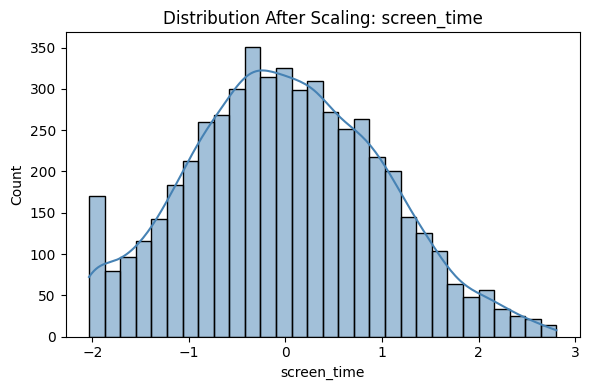

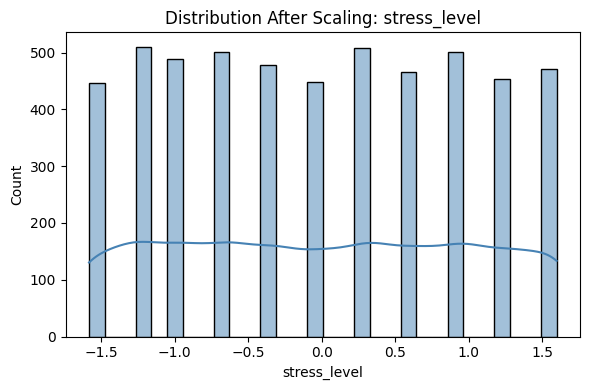

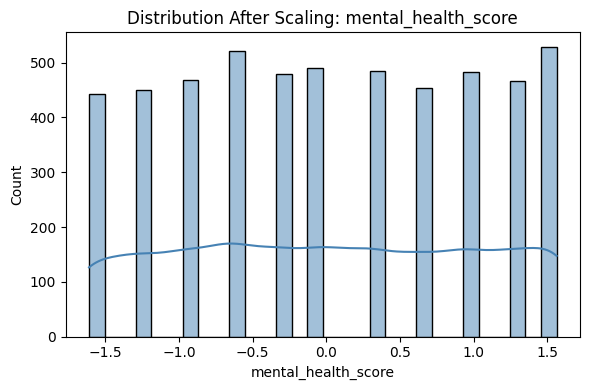

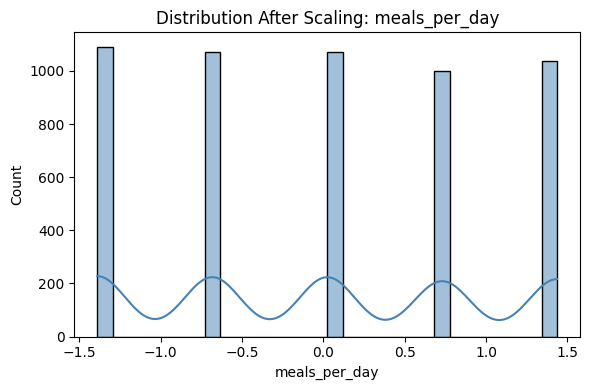

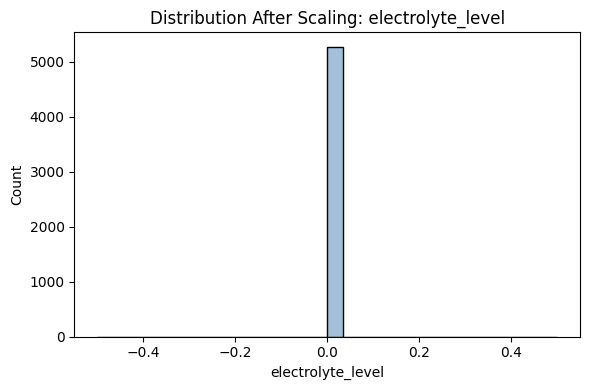

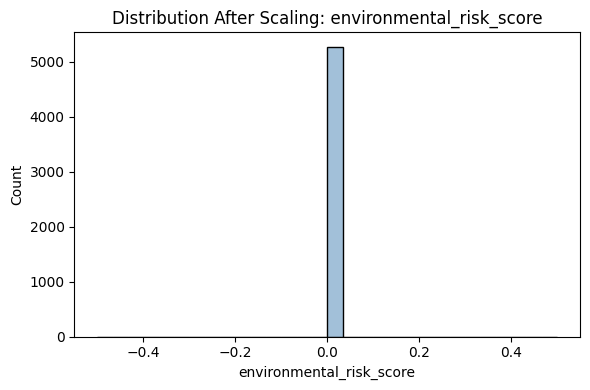

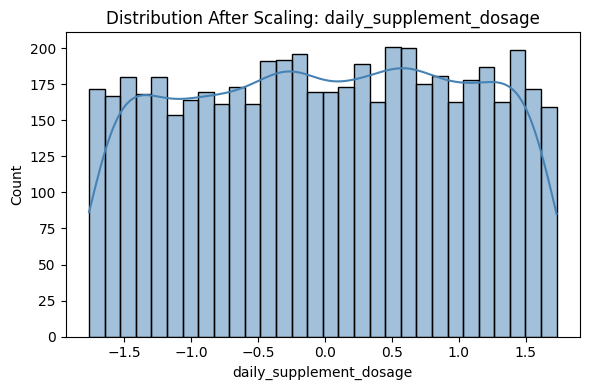

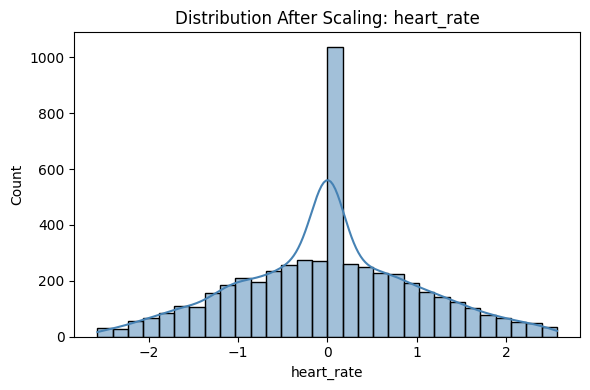

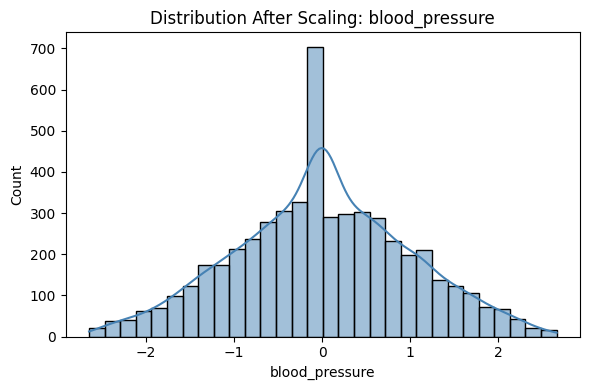

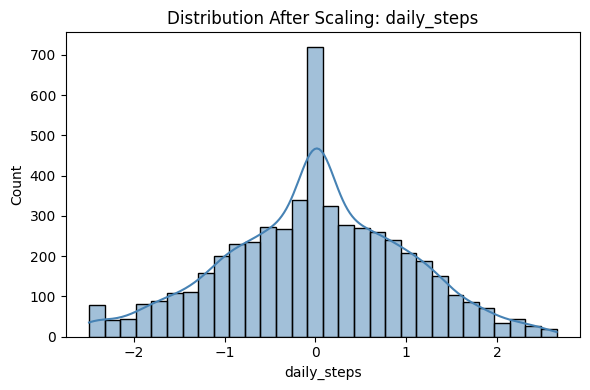

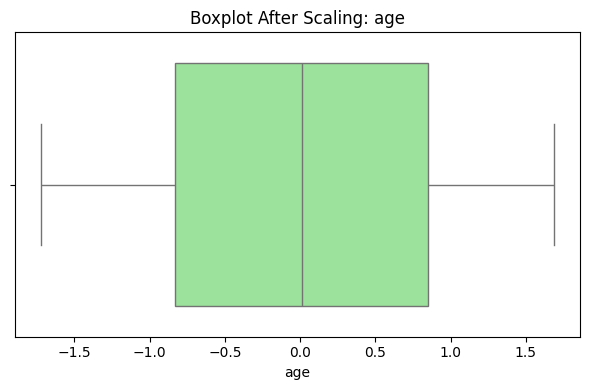

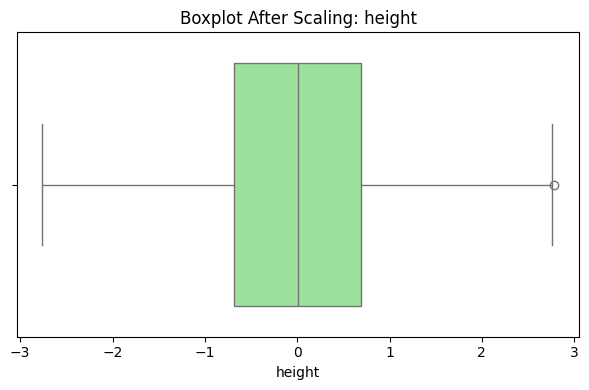

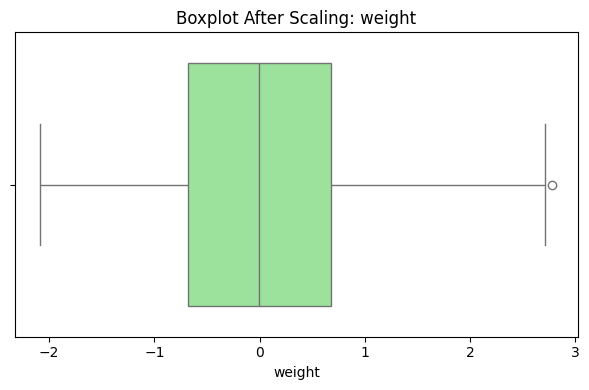

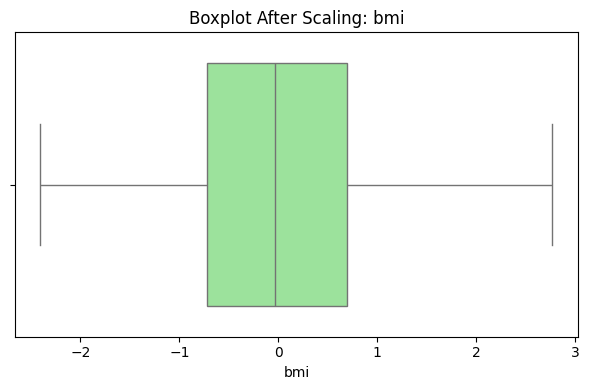

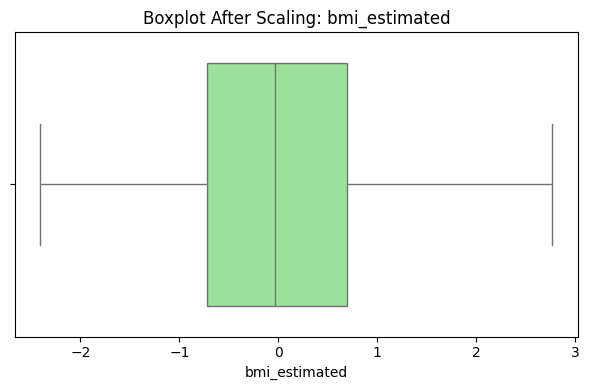

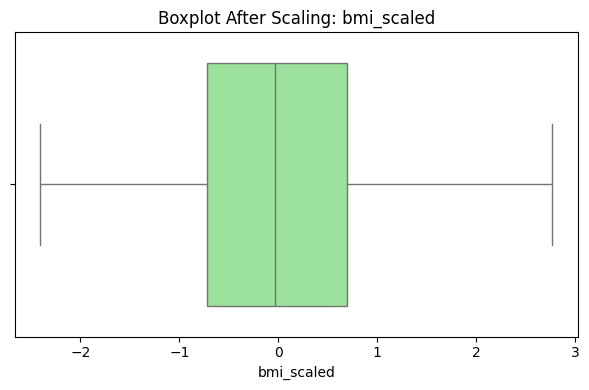

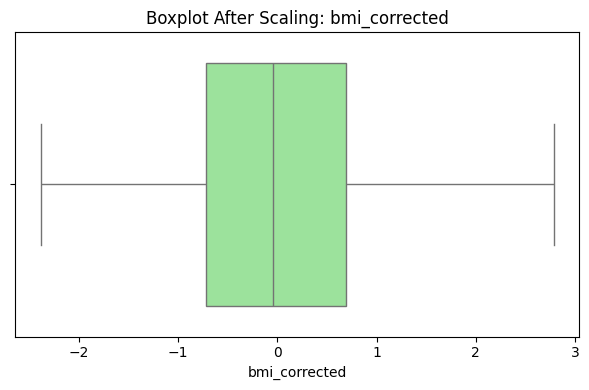

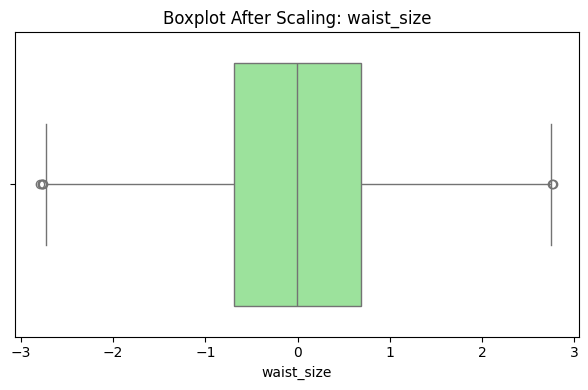

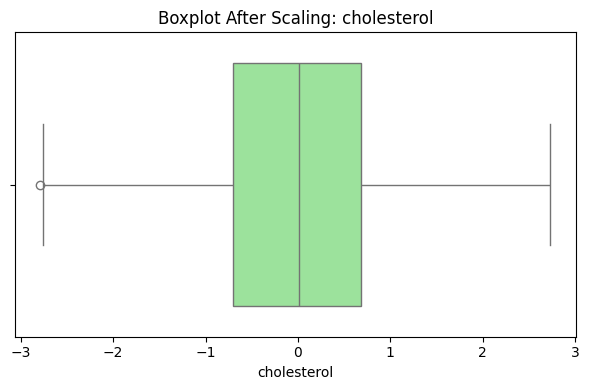

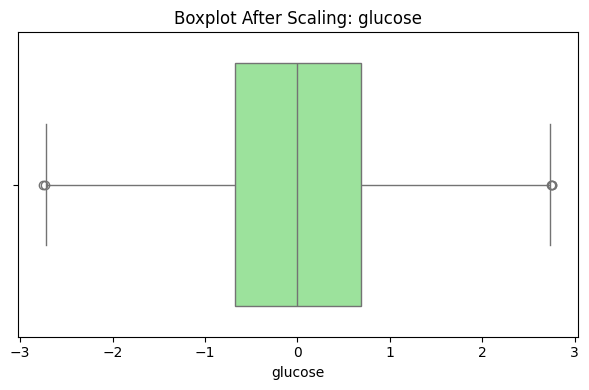

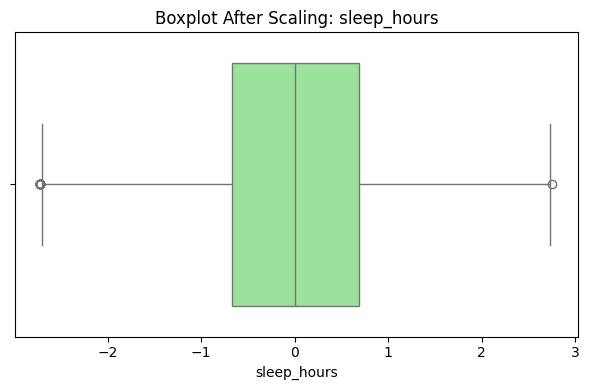

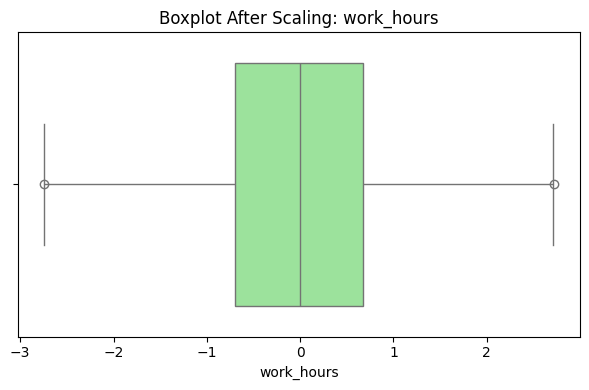

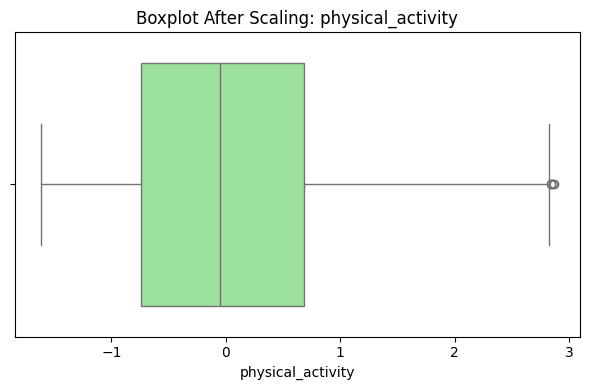

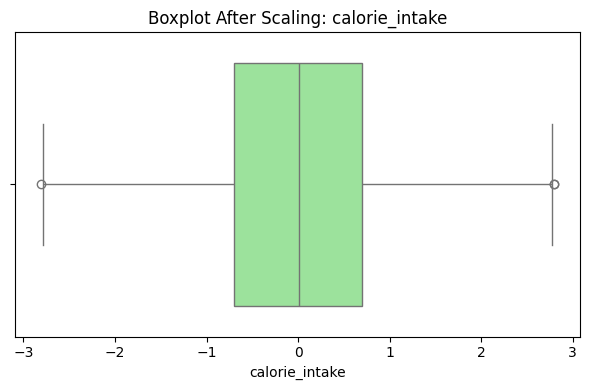

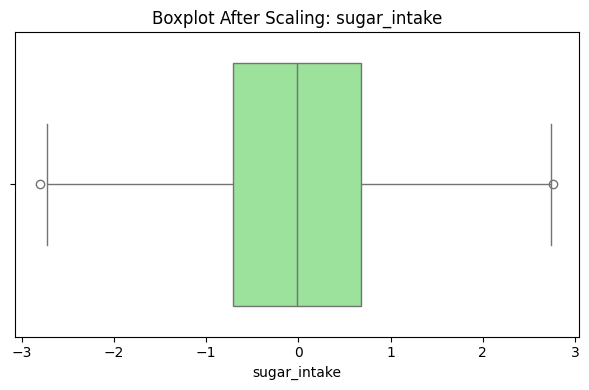

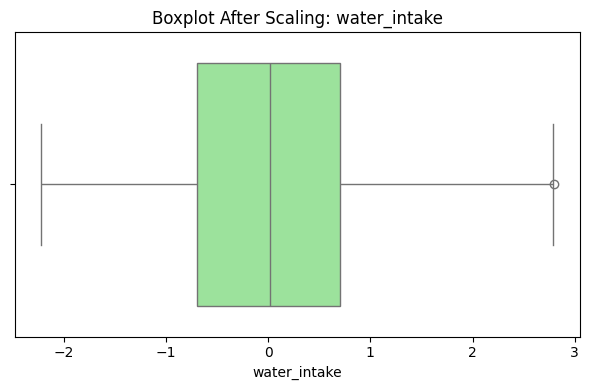

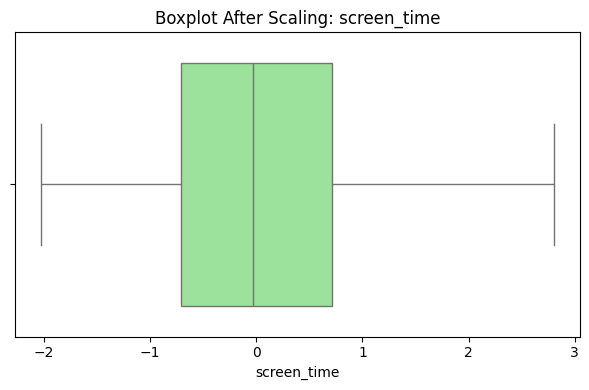

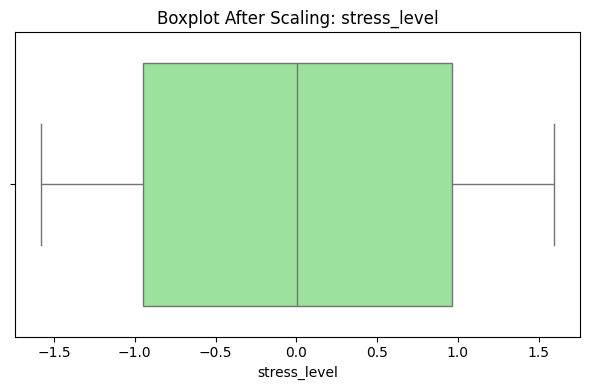

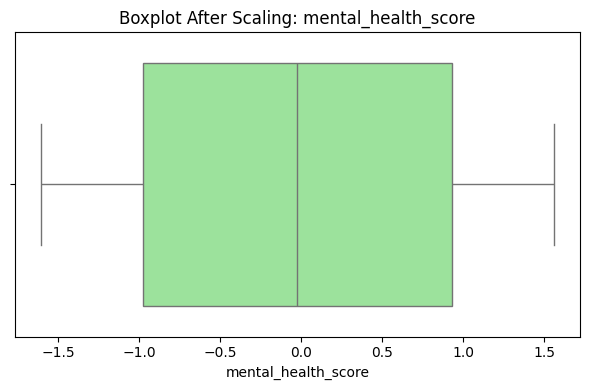

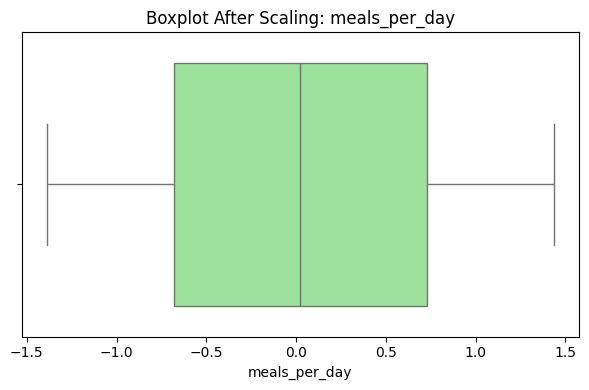

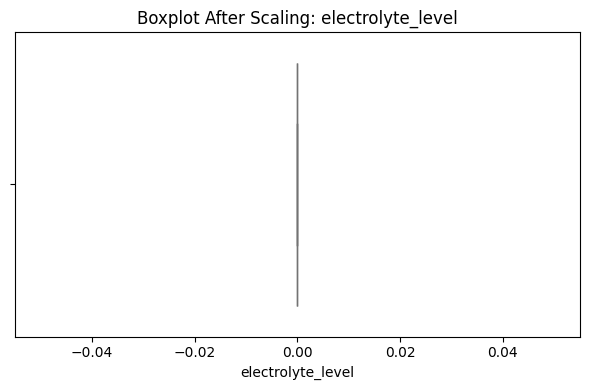

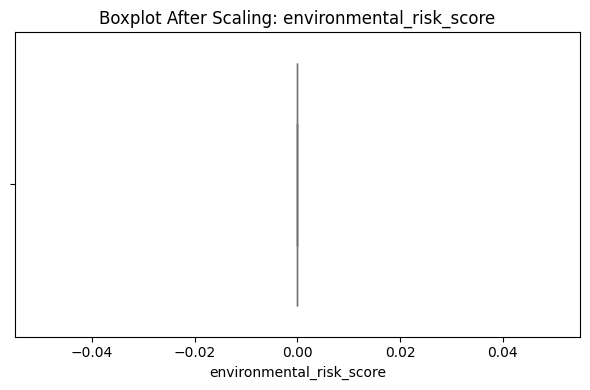

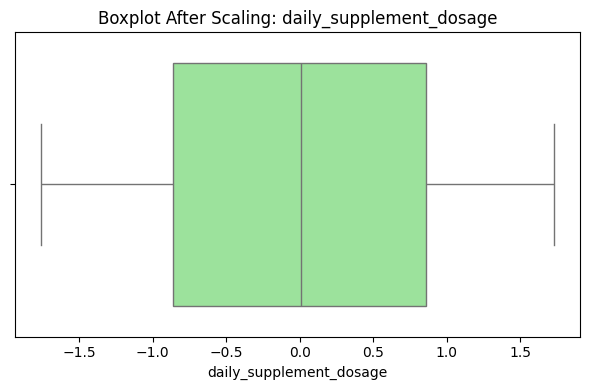

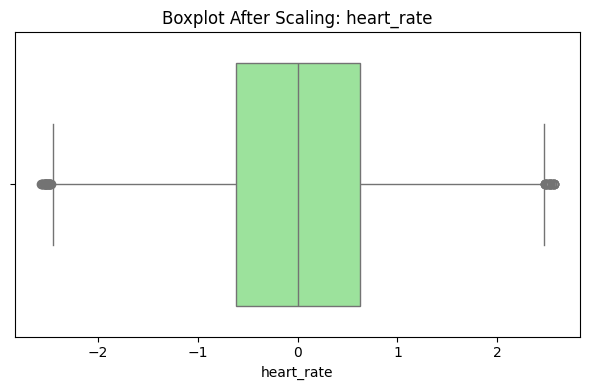

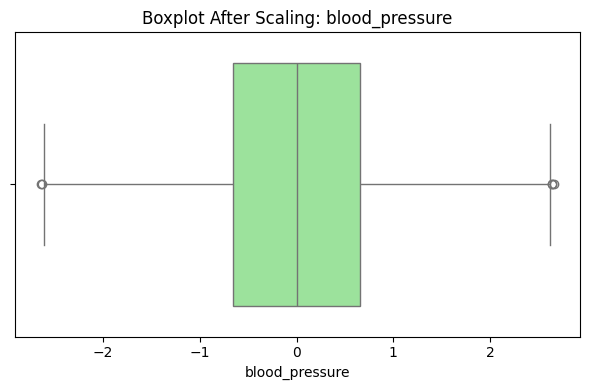

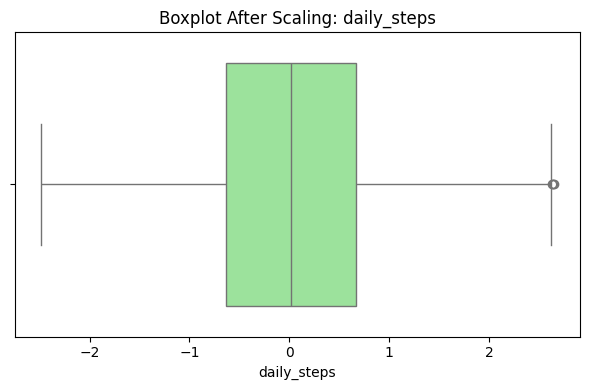

/tmp/ipython-input-1048128794.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Set2')


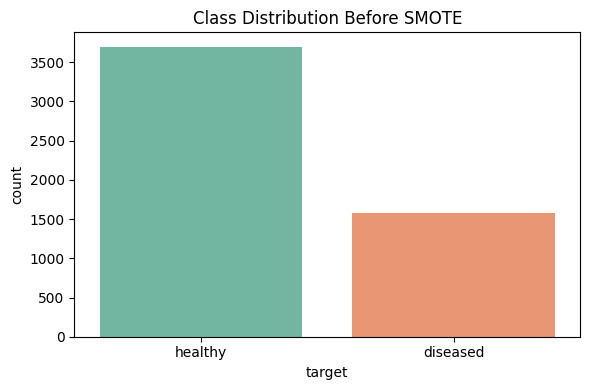

/tmp/ipython-input-1048128794.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette='Set1')


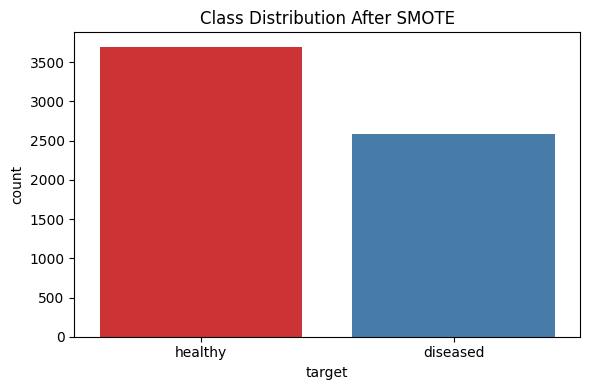

Scaled columns:
                age        height        weight           bmi  bmi_estimated  \
count  5.272000e+03  5.272000e+03  5.272000e+03  5.272000e+03   5.272000e+03   
mean  -1.981217e-16 -3.864722e-16  5.525844e-16 -2.762922e-17  -2.762922e-17   
std    1.000095e+00  1.000095e+00  1.000095e+00  1.000095e+00   1.000095e+00   
min   -1.725220e+00 -2.758402e+00 -2.083245e+00 -2.404744e+00  -2.404744e+00   
25%   -8.296659e-01 -6.890640e-01 -6.841791e-01 -7.167096e-01  -7.167096e-01   
50%    9.916156e-03  9.822148e-03 -2.450556e-03 -3.861927e-02  -3.861927e-02   
75%    8.494982e-01  6.948690e-01  6.800346e-01  6.921175e-01   6.921175e-01   
max    1.689080e+00  2.776652e+00  2.782907e+00  2.770641e+00   2.770641e+00   

         bmi_scaled  bmi_corrected    waist_size   cholesterol       glucose  \
count  5.272000e+03   5.272000e+03  5.272000e+03  5.272000e+03  5.272000e+03   
mean  -4.602624e-16  -1.812747e-16  1.283074e-15 -6.267116e-17  8.827874e-17   
std    1.000095e+00   1

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ✅ Step 1: Define the columns to scale
scale_cols = [
    'age', 'height', 'weight', 'bmi', 'bmi_estimated', 'bmi_scaled', 'bmi_corrected',
    'waist_size', 'cholesterol', 'glucose', 'sleep_hours', 'work_hours',
    'physical_activity', 'calorie_intake', 'sugar_intake', 'water_intake',
    'screen_time', 'stress_level', 'mental_health_score', 'meals_per_day',
    'electrolyte_level', 'environmental_risk_score', 'daily_supplement_dosage',
    'heart_rate', 'blood_pressure', 'daily_steps'
]

# ✅ Step 2: Keep only the columns that exist in the current DataFrame
existing_cols = [col for col in scale_cols if col in df.columns]

# ✅ Step 3: Apply StandardScaler to normalize selected columns
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[existing_cols] = scaler.fit_transform(df[existing_cols])

# 📊 Step 3.5: Visualize scaled distributions
for col in existing_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_scaled[col], kde=True, bins=30, color='steelblue')
    plt.title(f'Distribution After Scaling: {col}')
    plt.tight_layout()
    plt.show()

# 📦 Step 3.6: Box plots to inspect outliers
for col in existing_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_scaled[col], color='lightgreen')
    plt.title(f'Boxplot After Scaling: {col}')
    plt.tight_layout()
    plt.show()

# ✅ Step 4: Define feature matrix and target vector
X_scaled = df_scaled[existing_cols]
y = df['target']  # Replace 'target' with your actual label column name

# 📈 Step 4.5: Visualize class imbalance before SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='Set2')
plt.title("Class Distribution Before SMOTE")
plt.tight_layout()
plt.show()

# ✅ Step 5: Apply SMOTE to reduce class imbalance
smote = SMOTE(random_state=24, sampling_strategy=0.7)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# 📈 Step 5.5: Visualize class distribution after SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x=y_resampled, palette='Set1')
plt.title("Class Distribution After SMOTE")
plt.tight_layout()
plt.show()

# ✅ Step 6: Confirm scaling results with summary statistics
print("Scaled columns:")
print(df_scaled[existing_cols].describe())

In [49]:
df = df_scaled
df.head()

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,...,occupation_Engineer,occupation_Farmer,occupation_Teacher,device_usage_encoded,healthcare_access_encoded,insurance_encoded,sunlight_exposure_encoded,family_history_encoded,pet_owner_encoded,target_encoded
1,2,1.129359,Female,-0.699148,1.984423,2.192664,2.192664,2.192664,2.154596,0.048630,...,True,False,False,1.0,1.0,0,2.0,1,0,1
2,3,-0.158000,Male,0.737312,0.780144,0.242585,0.242585,0.242585,0.227142,0.447368,...,False,False,True,2.0,2.0,1,2.0,0,0,1
3,4,-0.941610,Female,0.208566,-0.454565,-0.526371,-0.526371,-0.526371,-0.551025,1.314206,...,False,False,True,0.0,1.0,0,2.0,0,1,1
4,5,0.625610,Female,-0.658178,-2.083245,-1.652138,-1.652138,-1.652138,-1.668401,-1.358948,...,False,False,False,0.0,1.0,1,2.0,1,1,1
6,7,1.633108,Female,-0.397319,-0.321391,-0.131550,-0.131550,-0.131550,-0.149505,-1.459375,...,True,False,False,1.0,0.0,1,2.0,0,0,1


In [50]:
#5- Feature Selection - IT24100390

In [51]:
from sklearn.feature_selection import VarianceThreshold

# Remove features with variance below 0.01
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(df.select_dtypes(include=[np.number]))

# Get selected column names
selected_cols = df.select_dtypes(include=[np.number]).columns[selector.get_support()]
print("Selected by variance:", selected_cols.tolist())


Selected by variance: ['survey_code', 'age', 'height', 'weight', 'bmi', 'bmi_estimated', 'bmi_scaled', 'bmi_corrected', 'waist_size', 'cholesterol', 'glucose', 'sleep_hours', 'work_hours', 'physical_activity', 'calorie_intake', 'sugar_intake', 'water_intake', 'screen_time', 'stress_level', 'mental_health_score', 'meals_per_day', 'daily_supplement_dosage', 'heart_rate', 'blood_pressure', 'daily_steps', 'gender_encoded', 'sleep_quality_encoded', 'smoking_level_encoded', 'mental_health_support_encoded', 'education_level_encoded', 'device_usage_encoded', 'healthcare_access_encoded', 'insurance_encoded', 'sunlight_exposure_encoded', 'family_history_encoded', 'pet_owner_encoded', 'target_encoded']


In [52]:
desired_cols = [
    'age', 'height', 'weight', 'bmi', 'waist_size', 'glucose', 'sleep_hours',
    'physical_activity', 'water_intake', 'meals_per_day', 'heart_rate',
    'blood_pressure', 'daily_steps', 'gender_encoded', 'family_history_encoded',
    'target_encoded'
]

# Your full variance-filtered list
variance_selected = [
    'survey_code', 'age', 'height', 'weight', 'bmi', 'bmi_estimated', 'bmi_scaled',
    'bmi_corrected', 'waist_size', 'cholesterol', 'glucose', 'sleep_hours',
    'work_hours', 'physical_activity', 'calorie_intake', 'sugar_intake',
    'water_intake', 'screen_time', 'stress_level', 'mental_health_score',
    'meals_per_day', 'daily_supplement_dosage', 'heart_rate', 'blood_pressure',
    'daily_steps', 'gender_encoded', 'sleep_quality_encoded', 'smoking_level_encoded',
    'mental_health_support_encoded', 'education_level_encoded', 'device_usage_encoded',
    'healthcare_access_encoded', 'insurance_encoded', 'sunlight_exposure_encoded',
    'family_history_encoded', 'pet_owner_encoded', 'target_encoded'
]

# Filter only the desired ones
selected_features = [col for col in desired_cols if col in variance_selected]
print("Final selected features:", selected_features)

df_selected = df[selected_features]
df=df_selected

Final selected features: ['age', 'height', 'weight', 'bmi', 'waist_size', 'glucose', 'sleep_hours', 'physical_activity', 'water_intake', 'meals_per_day', 'heart_rate', 'blood_pressure', 'daily_steps', 'gender_encoded', 'family_history_encoded', 'target_encoded']


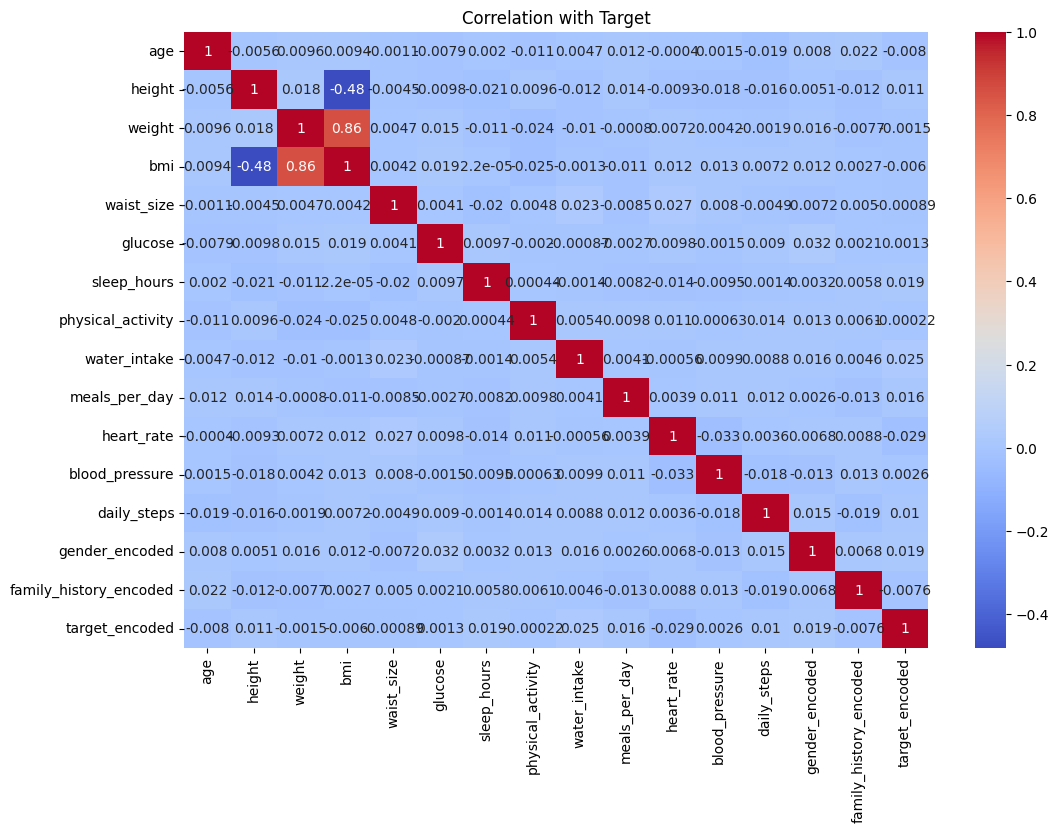

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Remove 'target_encoded' if it's already in selected_features
features_to_plot = [f for f in selected_features if f != 'target_encoded']

# Add 'target_encoded' back explicitly for correlation
features_to_plot.append('target_encoded')

plt.figure(figsize=(12, 8))
sns.heatmap(df[features_to_plot].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation with Target")
plt.show()

In [54]:
#6- Dimensionality Reduction(PCA) - IT24100419

Original feature count: 15
Reduced feature count: 14
Explained variance ratio per component:
[0.132 0.071 0.07  0.07  0.069 0.069 0.067 0.067 0.066 0.065 0.064 0.064
 0.063 0.062]


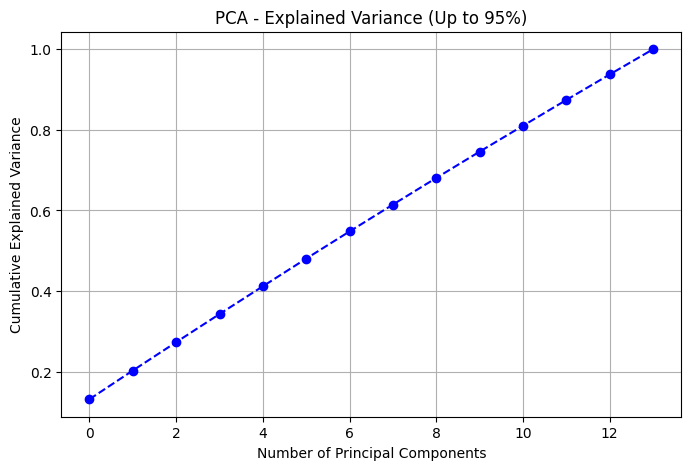

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,target
0,3.073162,-0.426444,0.902105,1.150183,0.560400,0.401625,-0.983341,-0.387981,1.879006,-0.626488,0.801077,3.013280,-0.019544,-0.321731,1
1,0.371891,0.085987,0.624492,-1.682245,0.175637,1.029583,0.419040,-0.008896,-0.656040,0.965003,-0.325343,-1.441256,0.529521,-0.359303,1
2,-0.631468,-1.093595,-0.551202,-0.944305,-1.478163,-0.119273,3.272508,-0.828053,0.803158,-0.032121,0.349868,-0.427514,-0.682351,0.547048,1
3,-2.155508,-0.746927,-1.936051,0.995288,-0.505506,-0.826799,-0.882820,0.583159,0.954189,-1.327710,-0.323829,-0.134447,-0.099577,3.204944,1
4,-0.139935,-0.816129,1.456833,0.070823,0.181202,-0.797620,-0.995933,-1.844576,0.073205,-2.086838,0.839045,-0.869170,-1.300854,-0.207676,1


In [55]:
# 6 - Dimensionality Reduction using PCA (Corrected & Robust)
# ------------------------------------------------------------
# IT24100500

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Step 1: Identify features and target
# Replace 'target' with your actual target column name
X = df.drop('target_encoded', axis=1)
y = df['target_encoded']

# Step 2: Handle categorical columns (encode them)
# -------------------------------------------------
# Automatically encode any categorical (non-numeric) columns
X_encoded = X.copy()
for col in X_encoded.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

# Step 3: Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Step 4: Apply PCA (retain 95% of variance)
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Step 5: Inspect results
print(f"Original feature count: {X.shape[1]}")
print(f"Reduced feature count: {X_pca.shape[1]}")
print("Explained variance ratio per component:")
print(np.round(pca.explained_variance_ratio_, 3))

# Step 6: Visualize explained variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='b')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance (Up to 95%)')
plt.grid(True)
plt.show()

# Step 7: Create PCA DataFrame
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_columns)
df_pca['target'] = y.values

# Step 8: Display sample of reduced data
df_pca.head()


In [56]:
print(df.columns)

Index(['age', 'height', 'weight', 'bmi', 'waist_size', 'glucose',
       'sleep_hours', 'physical_activity', 'water_intake', 'meals_per_day',
       'heart_rate', 'blood_pressure', 'daily_steps', 'gender_encoded',
       'family_history_encoded', 'target_encoded'],
      dtype='object')


In [57]:
#Model_Selection

In [59]:
# Design 1
# Goal: Predict target class using health-related features
# Technique: Logistic Regression (binary classification)
# Reason: Simple, interpretable, works well with linearly separable data

from sklearn.linear_model import LogisticRegression

In [61]:
#Implement
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['target', 'target_encoded', 'survey_code'], errors='ignore')
y = df['target_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [62]:
#Tune (Hyperparameter Manual Search)
from sklearn.metrics import accuracy_score, f1_score

C_values = [0.01, 0.1, 1, 10, 100]
penalties = ['l1', 'l2']
solvers = ['liblinear', 'saga']

results = []

for C in C_values:
    for p in penalties:
        for s in solvers:
            try:
                model = LogisticRegression(C=C, penalty=p, solver=s, max_iter=1000)
                model.fit(X_train_scaled, y_train)
                preds = model.predict(X_test_scaled)
                acc = accuracy_score(y_test, preds)
                f1 = f1_score(y_test, preds)
                results.append((C, p, s, acc, f1))
            except:
                continue

import pandas as pd
results_df = pd.DataFrame(results, columns=['C','Penalty','Solver','Accuracy','F1'])
best_row = results_df.loc[results_df['F1'].idxmax()]
print(best_row)

C                0.01
Penalty            l1
Solver      liblinear
Accuracy     0.701422
F1           0.824513
Name: 0, dtype: object


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       315
           1       0.70      1.00      0.82       740

    accuracy                           0.70      1055
   macro avg       0.35      0.50      0.41      1055
weighted avg       0.49      0.70      0.58      1055



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


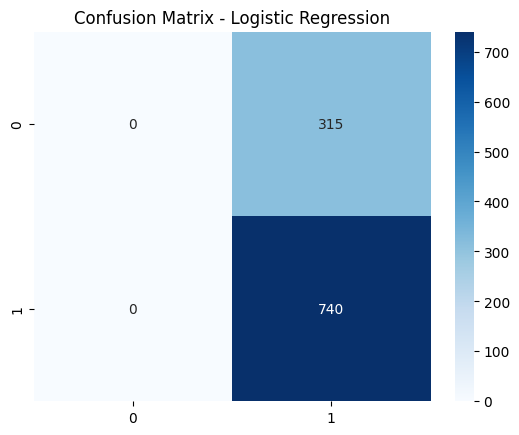

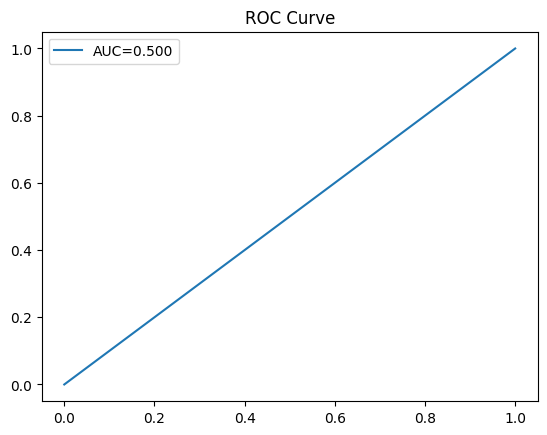

In [63]:
#Evaluate
best_model = LogisticRegression(
    C=best_row.C, penalty=best_row.Penalty, solver=best_row.Solver, max_iter=1000
)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns, matplotlib.pyplot as plt

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

y_score = best_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, y_score):.3f}")
plt.legend(); plt.title("ROC Curve"); plt.show()

In [64]:
#Validate (K-Fold Cross-Validation)
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
print("CV Accuracies:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

CV Accuracies: [0.7014218  0.70023697 0.70106762 0.70106762 0.70106762]
Mean CV Accuracy: 0.7009723229495202


In [65]:
#Compare Variations
# Compare default vs tuned Logistic Regression
default_lr = LogisticRegression(max_iter=1000)
default_lr.fit(X_train_scaled, y_train)
y_def = default_lr.predict(X_test_scaled)

compare_df = pd.DataFrame({
    'Model':['Default','Tuned'],
    'Accuracy':[accuracy_score(y_test,y_def),accuracy_score(y_test,y_pred)],
    'F1':[f1_score(y_test,y_def),f1_score(y_test,y_pred)]
})
print(compare_df)

     Model  Accuracy        F1
0  Default  0.701422  0.824513
1    Tuned  0.701422  0.824513


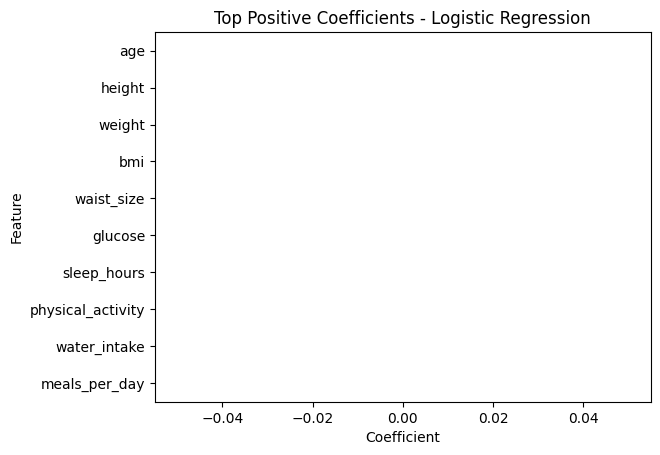

In [66]:
#Explain Results & Insights
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

sns.barplot(y='Feature', x='Coefficient', data=coef_df.head(10))
plt.title("Top Positive Coefficients - Logistic Regression")
plt.show()

# Interpretation example:
# Positive coefficients -> features increasing disease risk
# Negative coefficients -> protective features